In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

import robomimic
import robomimic.dev.hparam.utils.pkl_utils as pkl_utils
import robomimic.dev.hparam.utils.plot_utils as plot_utils
import robomimic.dev.hparam.metrics.smoothness_metrics as SmoothnessMetrics
import robomimic.dev.hparam.metrics.metric_fn as EvalMetrics
import robomimic.dev.hparam.utils.stat_utils as stat_utils
import robomimic.dev.hparam.utils.demo_utils as demo_utils
import robomimic.dev.hparam.metrics.metric_fn as Metrics
from robomimic.dev.hparam.eval_suite import DemoEvalSuite

## Loading some pkl files to analyze

In [2]:
result_dir         = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug"

# baseline_dir       = "/home/wjung85/Repo/projects/FastIL/logs/baseline"
pkl_files_inp      = pkl_utils.get_result_pkl_files(result_dir, filter="inp")
pkl_files_guide    = pkl_utils.get_result_pkl_files(result_dir, filter="cls")
pkl_files_baseline = pkl_utils.get_result_pkl_files(result_dir, filter="bl")

# Try opening first pkl file to examine structure
example_pkl = pkl_files_baseline[0]
data = pkl_utils.load_result_pkl_file(example_pkl)

print(f"\nStructure for {os.path.basename(example_pkl)}:")
print(f"{len(pkl_files_inp)} Inpainting, {len(pkl_files_guide)} Guiding, {len(pkl_files_baseline)} Baseline")
print("-" * 50)
# pkl_utils.print_nested_structure(data["rollouts"]["demo_0"])

success_rate_list = []
for i in range(len(pkl_files_inp)):
    data = pkl_utils.load_result_pkl_file(pkl_files_inp[i])
    success_rate = EvalMetrics.average_success_eval_fn(data["stats"])
    success_rate_list.append(success_rate)

print("Inpainting: Max {:.3f}, Min {:.3f}, Mean {:.3f}".format(np.max(success_rate_list), np.min(success_rate_list), np.mean(success_rate_list)))

success_rate_list = []
for i in range(len(pkl_files_baseline)):
    data = pkl_utils.load_result_pkl_file(pkl_files_baseline[i])
    success_rate = EvalMetrics.average_success_eval_fn(data["stats"])
    success_rate_list.append(success_rate)

print("Baseline: Max {:.3f}, Min {:.3f}, Mean {:.3f}".format(np.max(success_rate_list), np.min(success_rate_list), np.mean(success_rate_list)))




Structure for square_image_action_horizon_16_additional_bl_iter_19_2025-01-16 22:22:09.181849.pkl:
3 Inpainting, 0 Guiding, 23 Baseline
--------------------------------------------------
Inpainting: Max 0.880, Min 0.840, Mean 0.862
Baseline: Max 0.867, Min 0.773, Mean 0.824


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


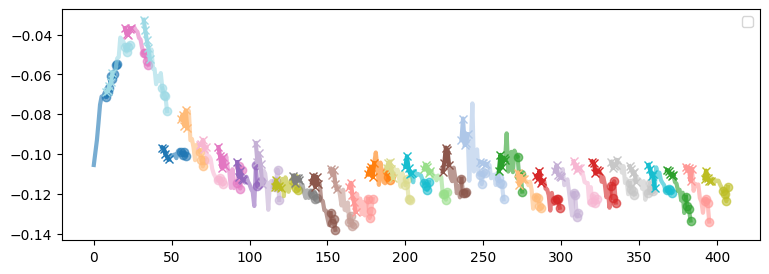

In [10]:
result_sparc_dir   = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug_sparc"
demo_idx           = 0
pkl_files_sparc    = pkl_utils.get_result_pkl_files(result_sparc_dir)
pkl_files_sparc    = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug_sparc/square_image_action_horizon_16_additional_bl_iter_0_2025-01-20 16:55:47.257411.pkl"
demo               = pkl_utils.load_demo_from_pkl(pkl_files_sparc, demo_idx = demo_idx)
_                  = plot_utils.plot_predictions(demo, action_idx=0)

In [73]:
def plot_diffusion(demo, action_idx, pred_idx = None, figsize = (9, 3), xlim = None, ylim = None):
    """
    Plot the predictions of a demo
    Args:
        demo (dict): The demo to plot
        action_idx (int): The index of the action to plot
    """
    Tne = demo['kwargs']['execute_n_actions']
    Td  = demo['kwargs']['inf_delay']
    Ta  = Tne + Td

    preds = demo['preds']

    diffusion_logs = demo["diffusion_logs"]

    timesteps = []
    actions = []

    window_size = 0
    for i, diffusion_log in enumerate(diffusion_logs):
        if len(diffusion_log) == 0:
            window_size += 1
            continue
        else:
            start_timestep = (i-window_size) * Ta
        
        actions_all = diffusion_log[0]["loss_log"]["actions_all"].detach().cpu().numpy()[0]
        T_diffuse = actions_all.shape[0]

        timesteps.append(np.arange(start_timestep, start_timestep + T_diffuse))
        actions.append(actions_all[:, action_idx])

    Trecent = window_size * Ta

    # viridis is a perceptually uniform colormap that's also colorblind-friendly
    # other good options: plasma, magma, inferno, cividis
    color_codes = np.linspace(0, 1, len(timesteps))
    np.random.shuffle(color_codes)
    colors = plt.cm.tab20(color_codes)

    alpha_pred = 0.6
    alpha_inpaint = 1.0
    
    plt.figure(figsize=figsize)
    for i, timestep in enumerate(timesteps):
        if (pred_idx is not None and i == pred_idx) or pred_idx is None:
            print("hi")
            plt.plot(timestep[:Trecent], actions[i][:Trecent], 'o-', color=colors[i], alpha=alpha_inpaint, linewidth=3)
            # plt.plot(timestep[Td:Ta+1], actions[i][Td:Ta+1], '-', color=colors[i], alpha=alpha_pred, linewidth=3) 
            # plt.plot(timestep[Ta:], actions[i][Ta:], 'o-', color=colors[i], alpha=alpha_pred, linewidth=3)

    
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

hi


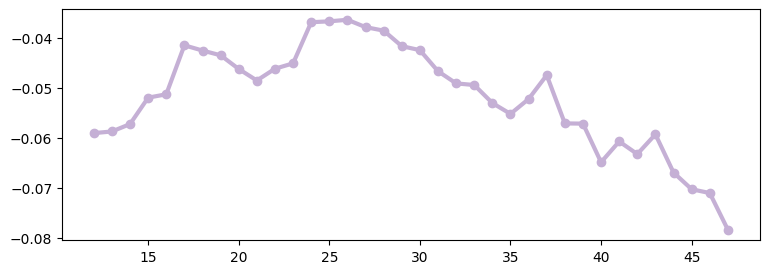

In [74]:
plot_diffusion(demo, action_idx=0, pred_idx=1)

In [37]:
demo["diffusion_logs"][4][90]['loss_log']['actions_all']

tensor([[[-5.9054e-02,  6.2968e-02,  9.3683e-01,  2.4665e+00,  1.8996e+00,
           4.5369e-02, -9.9745e-01,  1.6472e-04],
         [-5.8724e-02,  6.9301e-02,  9.3831e-01, -2.5069e+00, -1.8584e+00,
          -4.2194e-02, -9.9934e-01,  1.4102e-04],
         [-5.7244e-02,  7.4389e-02,  9.2479e-01, -2.5272e+00, -1.8330e+00,
          -4.6508e-02, -9.9900e-01, -5.3644e-07],
         [-5.1946e-02,  8.0390e-02,  9.2164e-01, -2.5389e+00, -1.7995e+00,
          -5.2183e-02, -9.9915e-01, -5.3644e-07],
         [-5.1271e-02,  7.8082e-02,  9.2057e-01, -2.5498e+00, -1.7723e+00,
          -5.3543e-02, -1.0000e+00, -5.3644e-07],
         [-4.1456e-02,  8.3788e-02,  9.1911e-01, -2.5607e+00, -1.7350e+00,
          -5.1436e-02, -9.9855e-01,  4.3154e-04],
         [-4.2503e-02,  8.3258e-02,  9.1547e-01, -2.5824e+00, -1.6986e+00,
          -4.6574e-02, -9.9842e-01,  1.0000e+00],
         [-4.3457e-02,  8.6036e-02,  9.1171e-01, -2.5993e+00, -1.6607e+00,
          -4.2980e-02, -1.0000e+00,  1.0000e+00],


In [21]:
import torch
list(demo["diffusion_logs"].values())[0]["loss_log"]


{'sparc_loss': tensor(2.3813, device='cuda:0', requires_grad=True),
 'fft': (tensor([ 0.0000,  0.3125,  0.6250,  0.9375,  1.2500,  1.5625,  1.8750,  2.1875,
           2.5000,  2.8125,  3.1250,  3.4375,  3.7500,  4.0625,  4.3750,  4.6875,
           5.0000,  5.3125,  5.6250,  5.9375,  6.2500,  6.5625,  6.8750,  7.1875,
           7.5000,  7.8125,  8.1250,  8.4375,  8.7500,  9.0625,  9.3750,  9.6875,
          10.0000], device='cuda:0'),
  tensor([1.0000, 0.1070, 0.0740, 0.0171, 0.0499, 0.0795, 0.0192, 0.0230, 0.0520,
          0.0154, 0.1031, 0.0335, 0.0562, 0.0119, 0.0135, 0.0785, 0.0158, 0.0011,
          0.0410, 0.0144, 0.0592, 0.0118, 0.0382, 0.0157, 0.0230, 0.0610, 0.0359,
          0.0310, 0.0344, 0.0074, 0.0427, 0.0307, 0.0550], device='cuda:0',
         requires_grad=True)),
 'fft_filtered': (tensor([ 0.0000,  0.3125,  0.6250,  0.9375,  1.2500,  1.5625,  1.8750,  2.1875,
           2.5000,  2.8125,  3.1250,  3.4375,  3.7500,  4.0625,  4.3750,  4.6875,
           5.0000,  5.3125

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


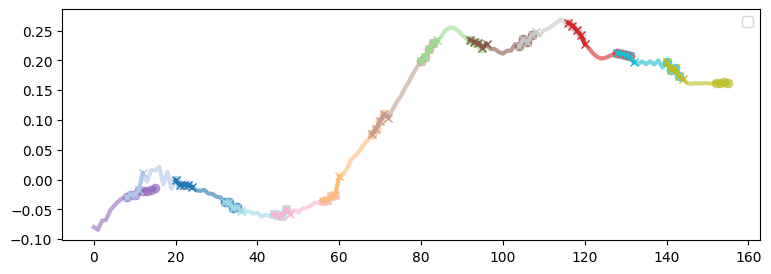

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


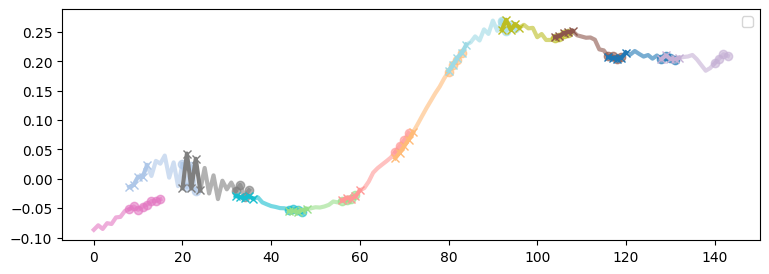

In [9]:
demo_idx = 6
demo = pkl_utils.load_demo_from_pkl(pkl_files_inp[0], demo_idx = demo_idx)
_ = plot_utils.plot_predictions(demo, action_idx=0)

demo = pkl_utils.load_demo_from_pkl(pkl_files_baseline[0], demo_idx = demo_idx)
_ = plot_utils.plot_predictions(demo, action_idx=0)

In [3]:
analyzer = DemoEvalSuite(pkl_files_baseline, lambda x: Metrics.sparc_cumul_eval_fn(x), metric_name="sparc_all")
analyzer.add_metric(eval_fn=lambda x: Metrics.sparc_cumul_eval_fn(x, time_horizon = 100), metric_name="sparc_all_upto_100")
analyzer.add_metric("sparc_all_upto_failure", Metrics.sparc_cumul_upto_failure_eval_fn)
analyzer.add_metric("success", Metrics.success_eval_fn)
analyzer.add_metric("failure_time", lambda x: Metrics.failure_time_eval_fn(x, quantile=0.1))
analyzer.add_metric("sparc_window_ws4", lambda x: Metrics.sparc_sliding_window_eval_fn(x, movement_type = "twist_cmd", sliding_window_size=4))
analyzer.add_metric("sparc_window_ws3", lambda x: Metrics.sparc_sliding_window_eval_fn(x, movement_type = "twist_cmd", sliding_window_size=3))
analyzer.add_metric("sparc_window_ws2", lambda x: Metrics.sparc_sliding_window_eval_fn(x, movement_type = "twist_cmd", sliding_window_size=2))
analyzer.add_metric("sparc_knot_ws4", lambda x: Metrics.sparc_knot(x, movement_type = "twist_cmd", sliding_window_size=4))
analyzer.add_metric("delta_eval_fn", Metrics.switch_delta_eval_fn)

100%|██████████| 23/23 [00:06<00:00,  3.47it/s]


Adding metric:  sparc_all_upto_100


100%|██████████| 23/23 [00:06<00:00,  3.49it/s]


Adding metric:  sparc_all_upto_failure


100%|██████████| 23/23 [00:09<00:00,  2.43it/s]


...

100%|██████████| 23/23 [00:08<00:00,  2.85it/s]


Adding metric:  sparc_knot_ws4


100%|██████████| 23/23 [00:10<00:00,  2.26it/s]


Adding metric:  delta_eval_fn


100%|██████████| 23/23 [00:03<00:00,  6.11it/s]


In [4]:
analyzer.add_metric(eval_fn=lambda x: Metrics.sparc_cumul_eval_fn(x, time_horizon = 84), metric_name="sparc_all_upto_84")

Adding metric:  sparc_all_upto_84


100%|██████████| 23/23 [00:06<00:00,  3.42it/s]


In [5]:
analyzer.aggregate_metric("sparc_window_ws4", "upto_10_q25", lambda x: np.quantile(x[:10], 0.25))
analyzer.aggregate_metric("sparc_window_ws3", "upto_10_q25", lambda x: np.quantile(x[:10], 0.25))
analyzer.aggregate_metric("sparc_window_ws2", "upto_10_q25", lambda x: np.quantile(x[:10], 0.25))
analyzer.aggregate_metric("sparc_knot_ws4", "upto_10_q25", lambda x: np.quantile(x[:10], 0.25))
analyzer.aggregate_metric("delta_eval_fn", "upto_10_q25", lambda x: np.quantile(x[:10], 0.25))

analyzer.aggregate_metric("sparc_window_ws4", "upto_10_q10", lambda x: np.quantile(x[:10], 0.1))
analyzer.aggregate_metric("sparc_window_ws3", "upto_10_q10", lambda x: np.quantile(x[:10], 0.1))
analyzer.aggregate_metric("sparc_window_ws2", "upto_10_q10", lambda x: np.quantile(x[:10], 0.1))
analyzer.aggregate_metric("sparc_knot_ws4", "upto_10_q10", lambda x: np.quantile(x[:10], 0.1))
analyzer.aggregate_metric("delta_eval_fn", "upto_10_q10", lambda x: np.quantile(x[:10], 0.1))

In [6]:
analyzer.aggregate_metric("sparc_window_ws4", "upto_7_q25", lambda x: np.quantile(x[:7], 0.25))
analyzer.aggregate_metric("sparc_window_ws3", "upto_7_q25", lambda x: np.quantile(x[:7], 0.25))
analyzer.aggregate_metric("sparc_window_ws2", "upto_7_q25", lambda x: np.quantile(x[:7], 0.25))
analyzer.aggregate_metric("sparc_knot_ws4", "upto_7_q25", lambda x: np.quantile(x[:7], 0.25))
analyzer.aggregate_metric("delta_eval_fn", "upto_7_q25", lambda x: np.quantile(x[:7], 0.25))

analyzer.aggregate_metric("sparc_window_ws4", "upto_7_q10", lambda x: np.quantile(x[:7], 0.1))
analyzer.aggregate_metric("sparc_window_ws3", "upto_7_q10", lambda x: np.quantile(x[:7], 0.1))
analyzer.aggregate_metric("sparc_window_ws2", "upto_7_q10", lambda x: np.quantile(x[:7], 0.1))
analyzer.aggregate_metric("sparc_knot_ws4", "upto_7_q10", lambda x: np.quantile(x[:7], 0.1))
analyzer.aggregate_metric("delta_eval_fn", "upto_7_q10", lambda x: np.quantile(x[:7], 0.1))

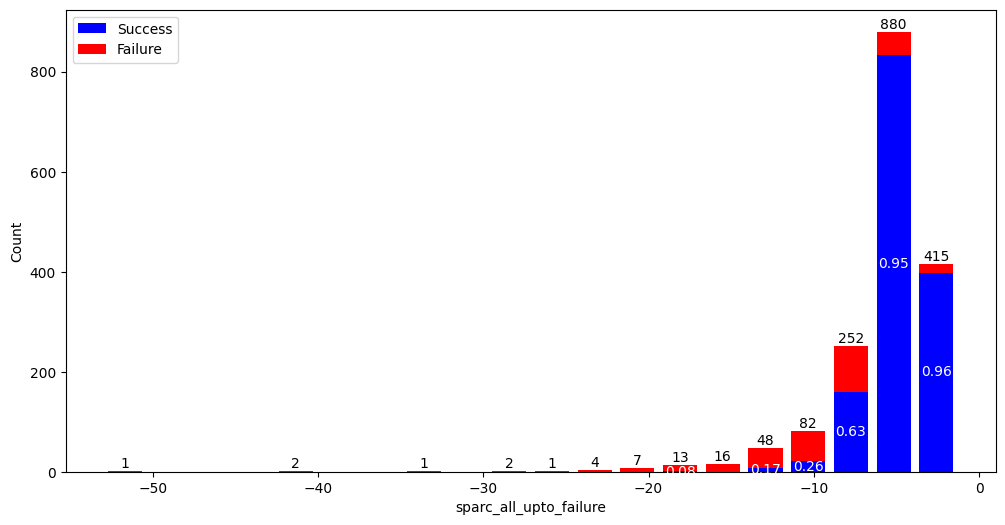

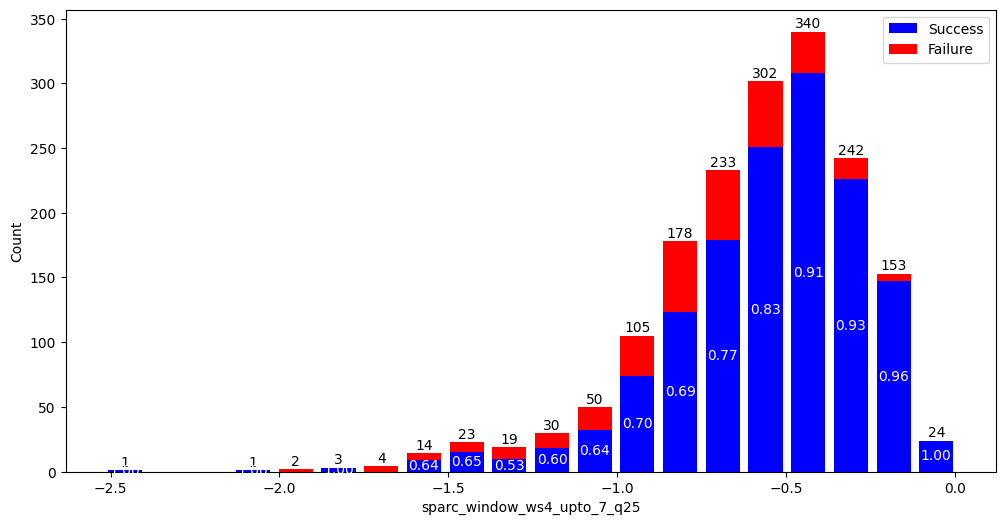

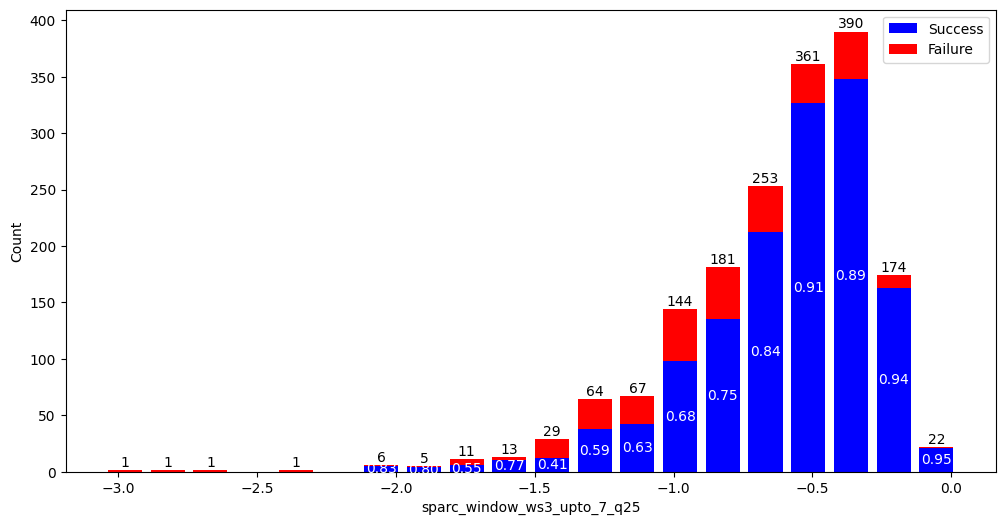

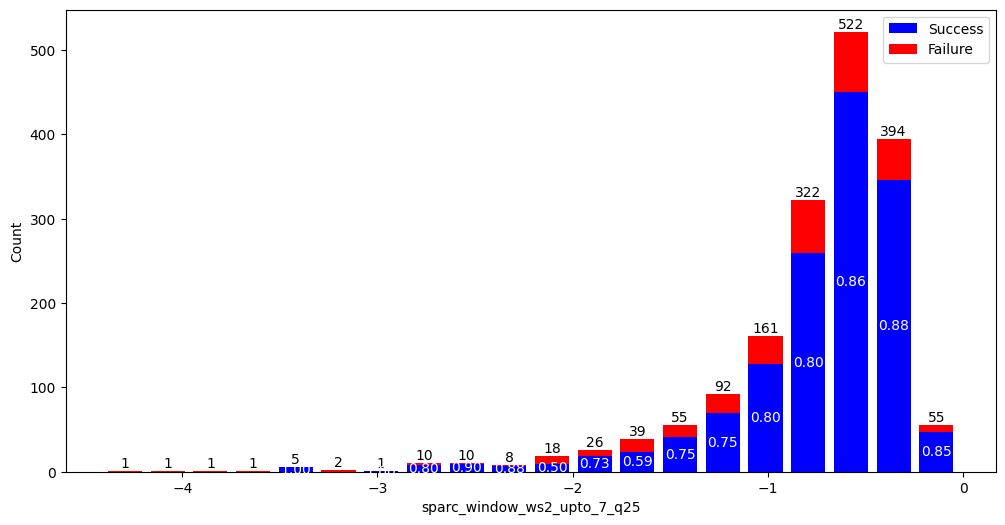

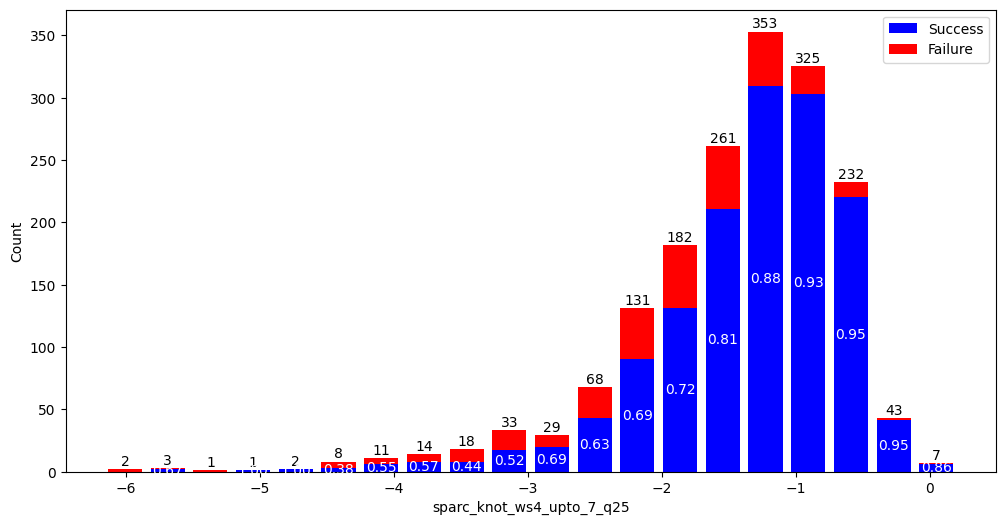

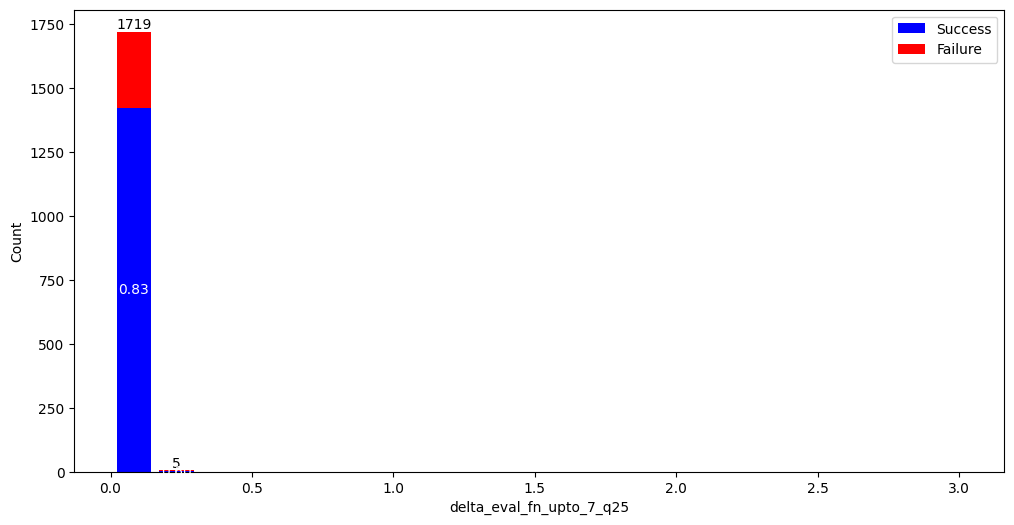

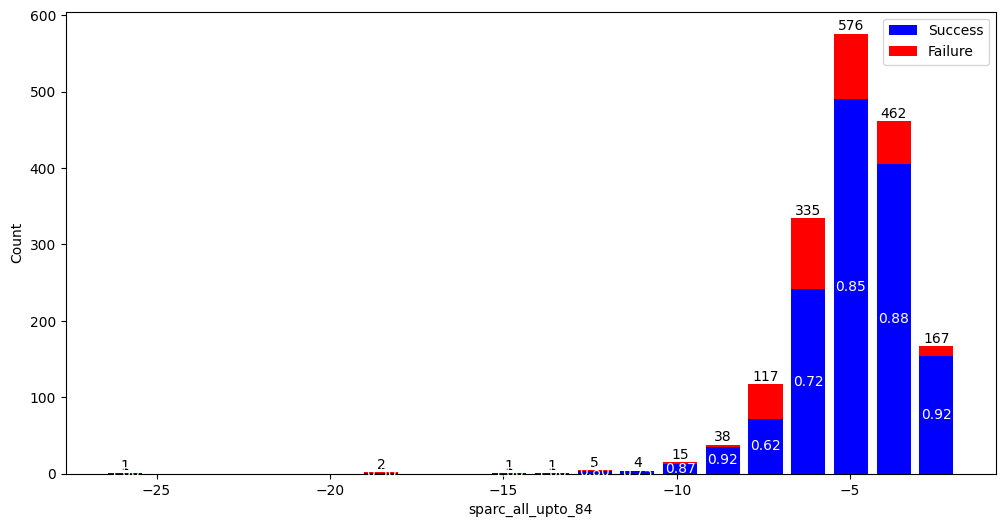

In [7]:
analyzer.plot_stacked_success_histogram("sparc_all_upto_failure", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws4_upto_7_q25", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws3_upto_7_q25", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws2_upto_7_q25", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_knot_ws4_upto_7_q25", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("delta_eval_fn_upto_7_q25", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_all_upto_84", figsize=(12, 6), bins=20)

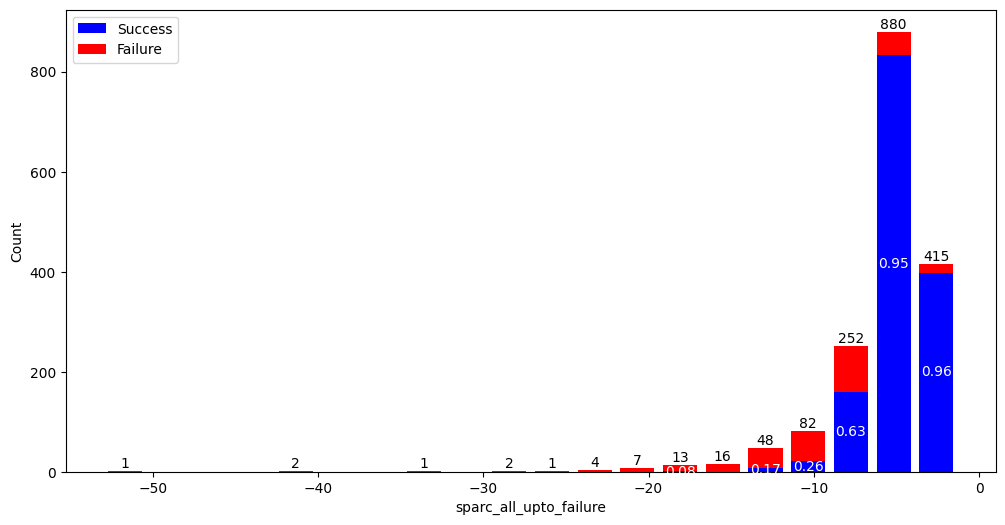

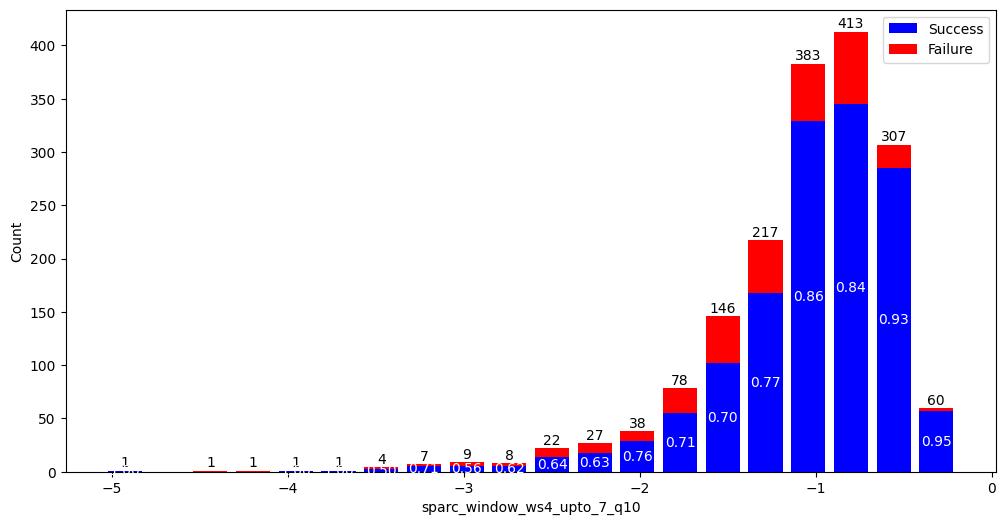

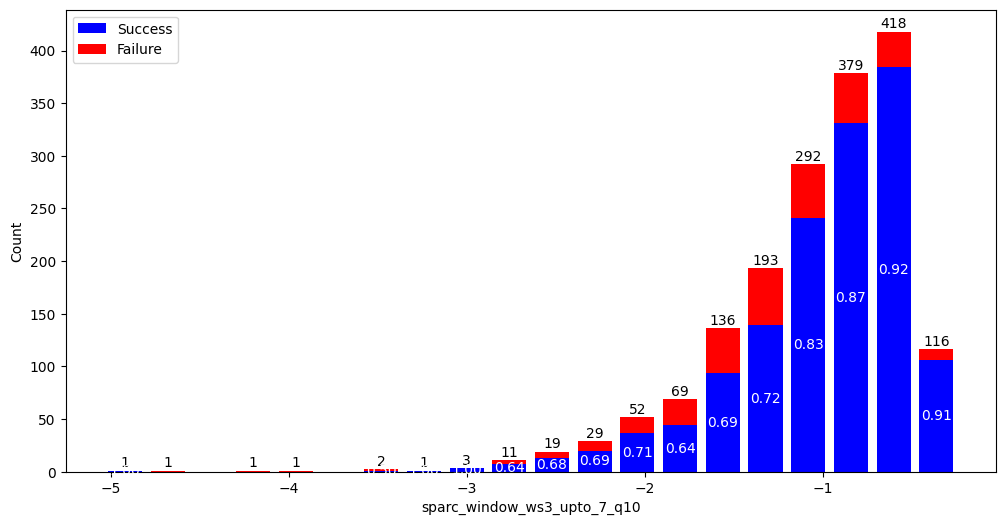

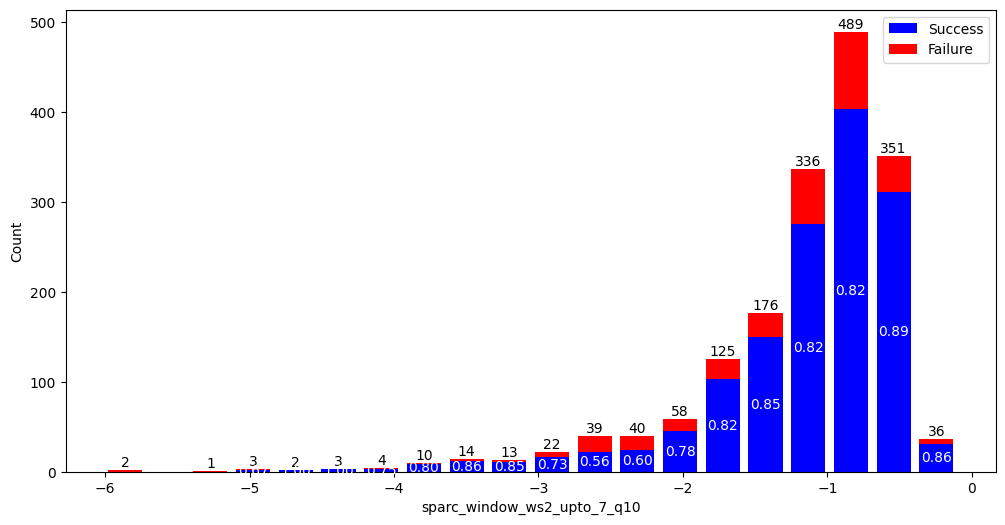

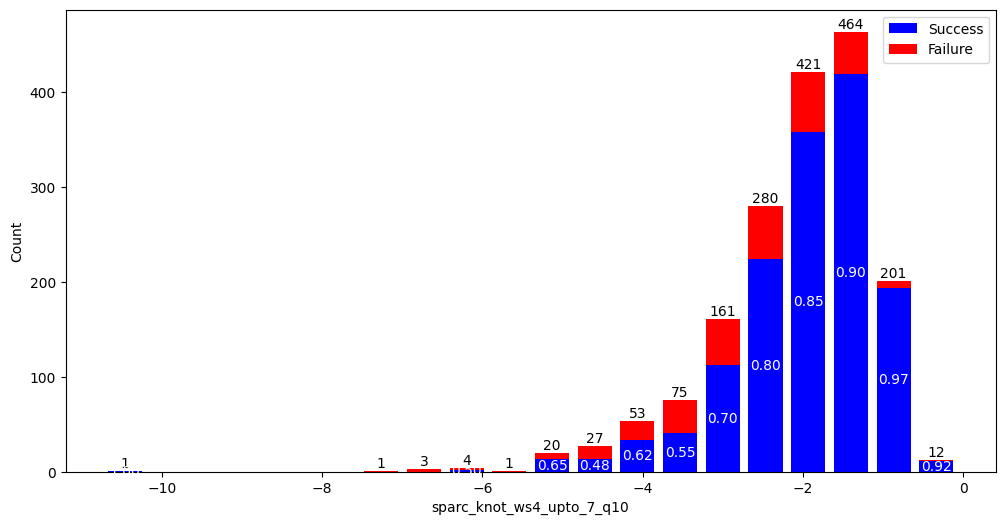

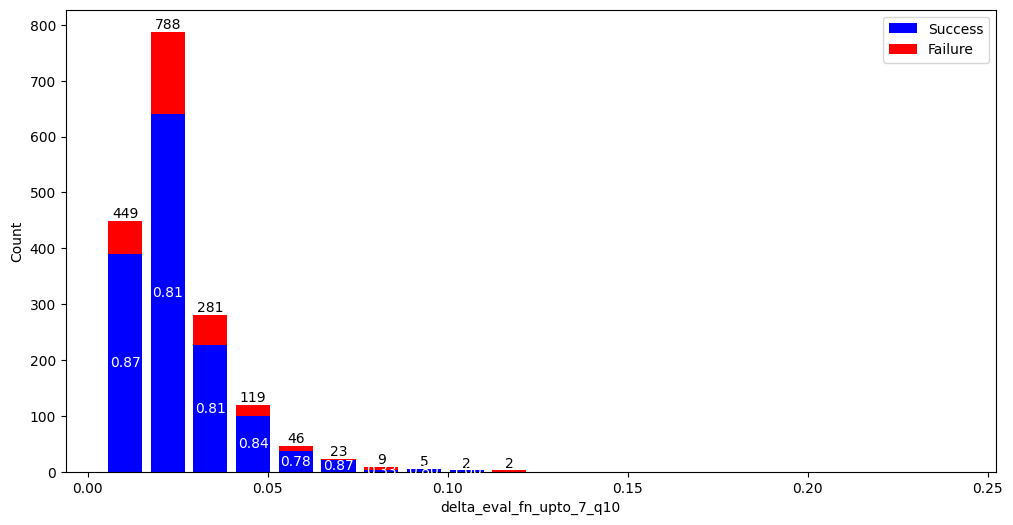

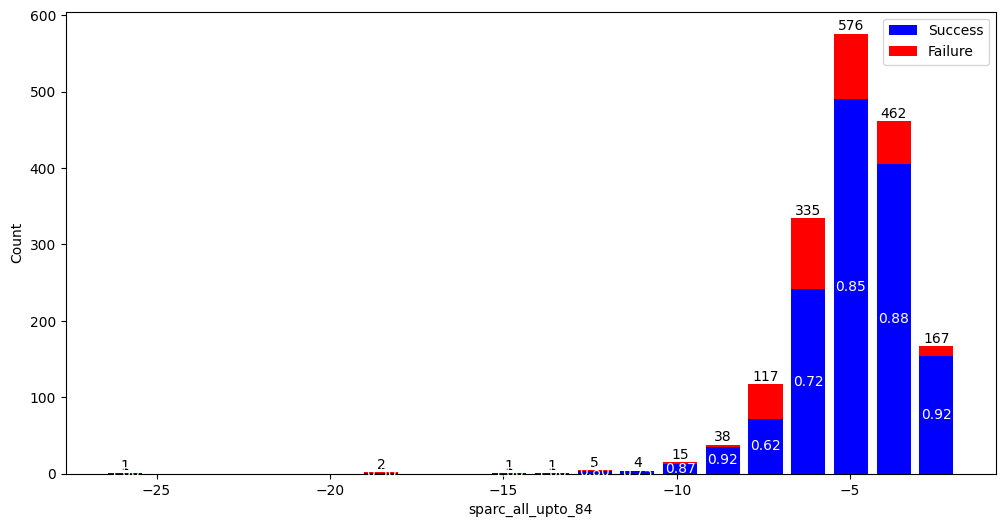

In [8]:
analyzer.plot_stacked_success_histogram("sparc_all_upto_failure", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws4_upto_7_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws3_upto_7_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws2_upto_7_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_knot_ws4_upto_7_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("delta_eval_fn_upto_7_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_all_upto_84", figsize=(12, 6), bins=20)

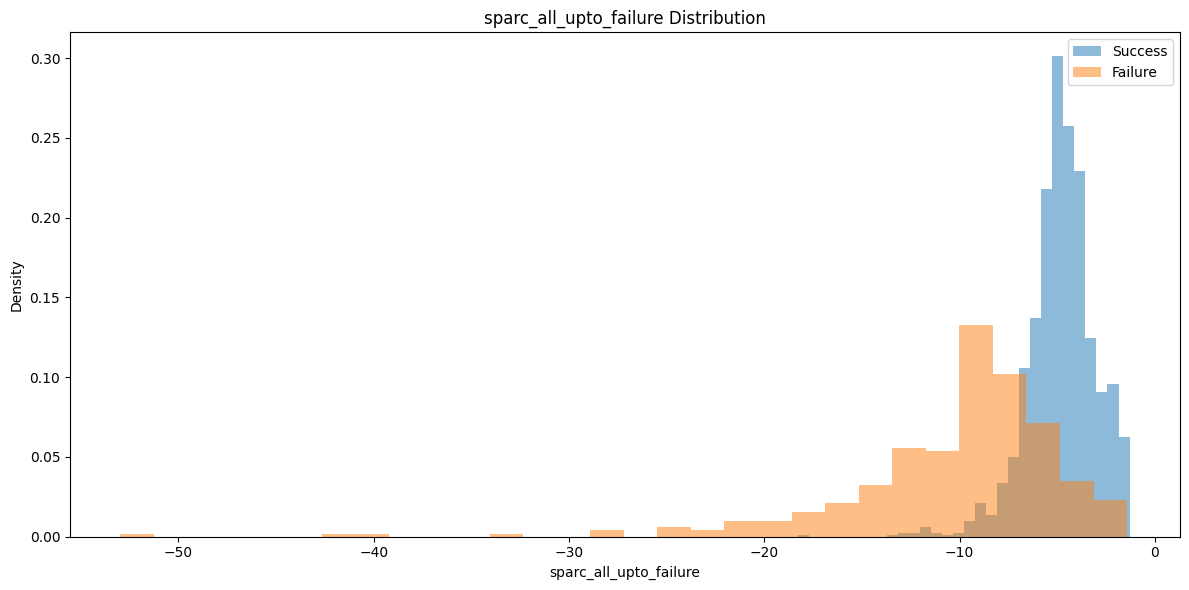

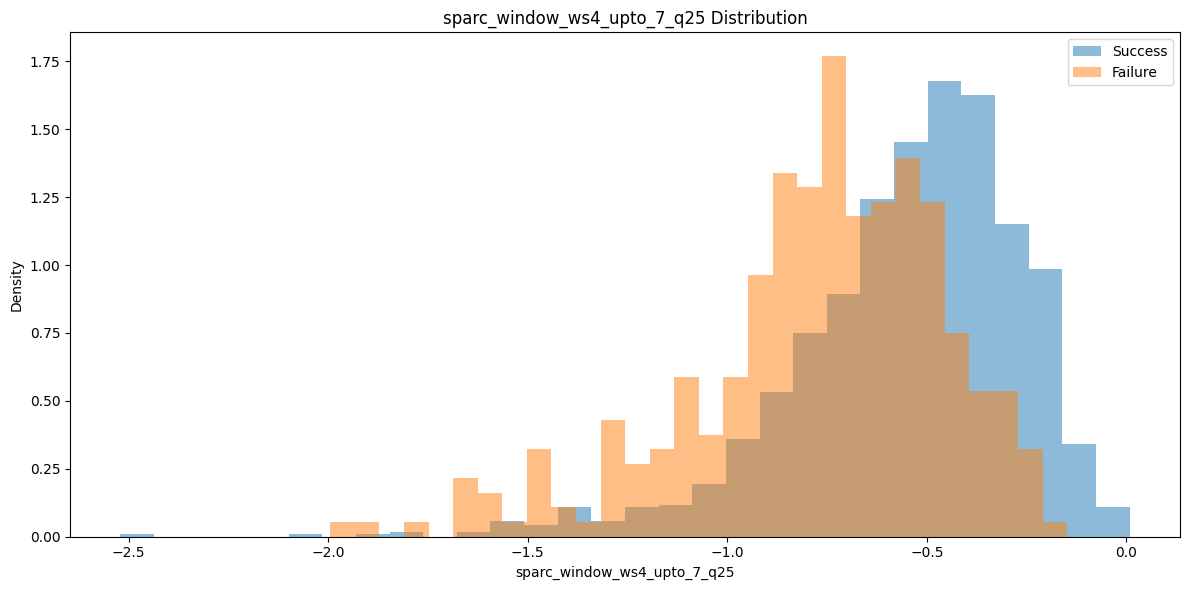

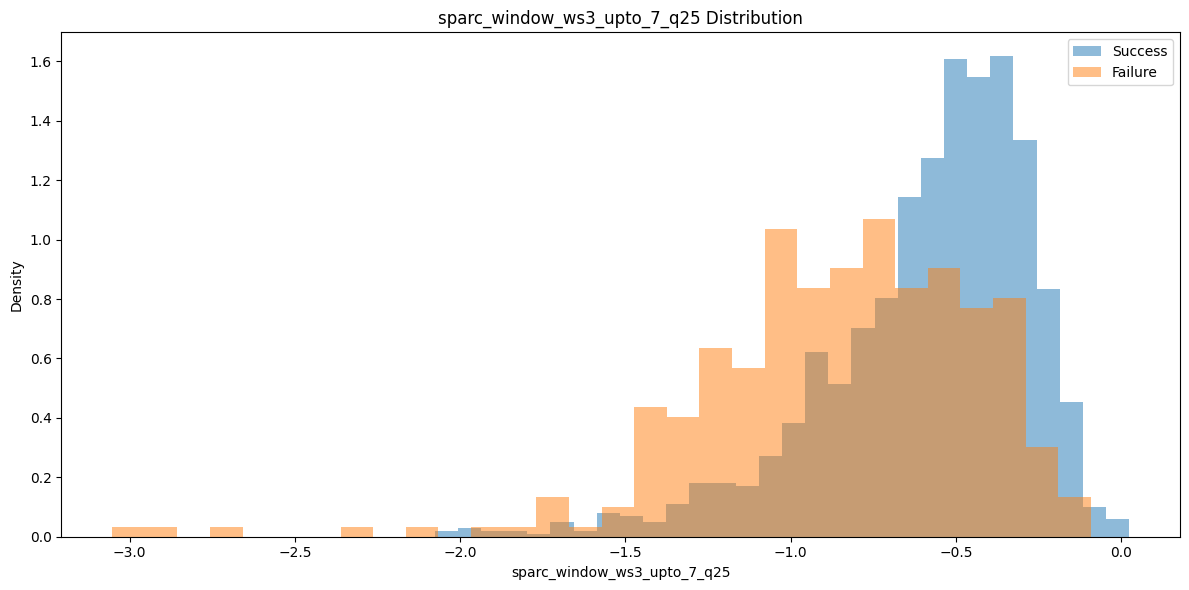

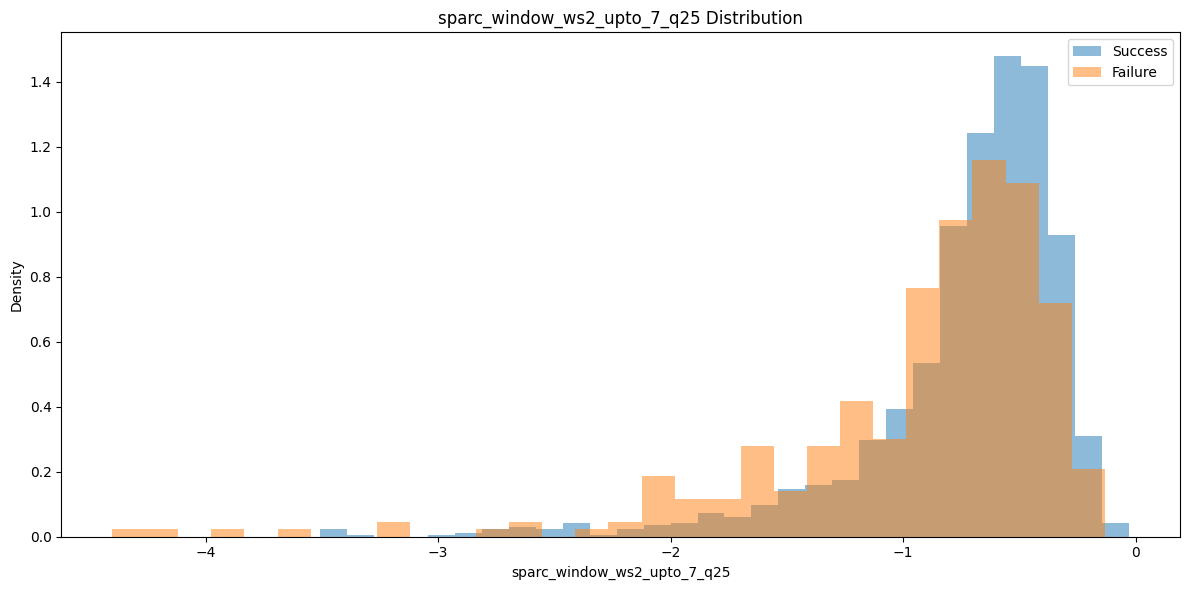

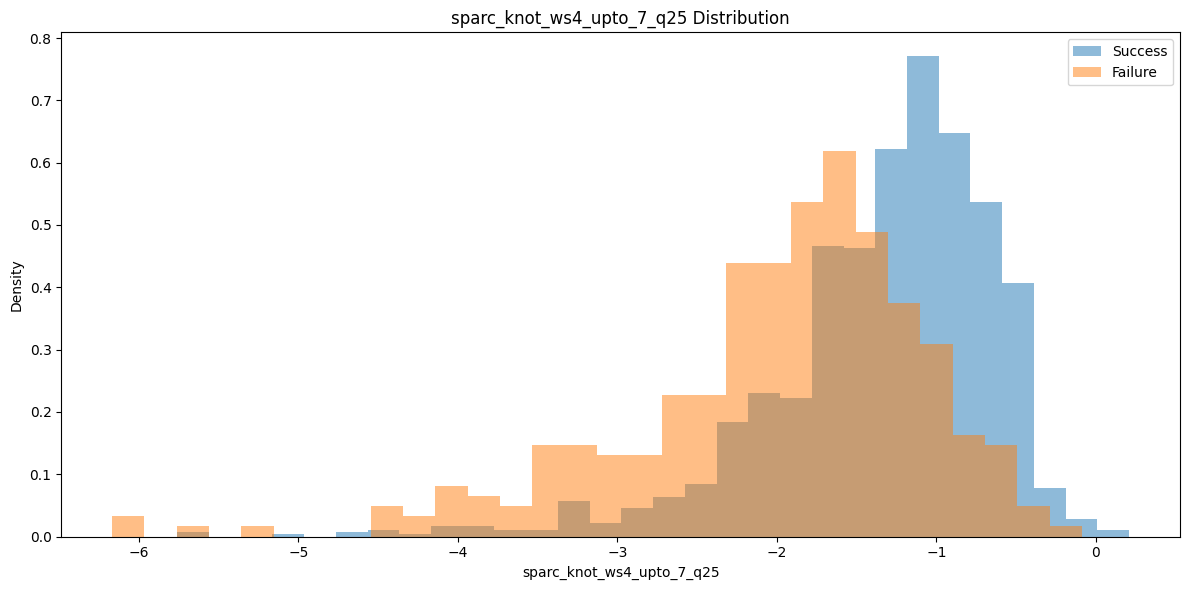

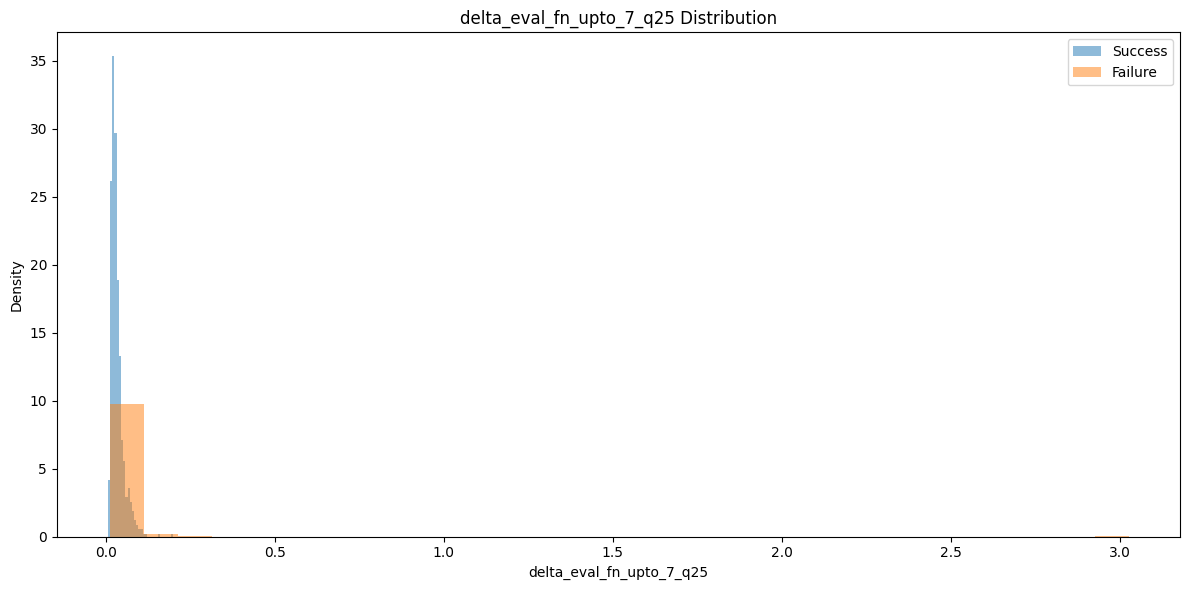

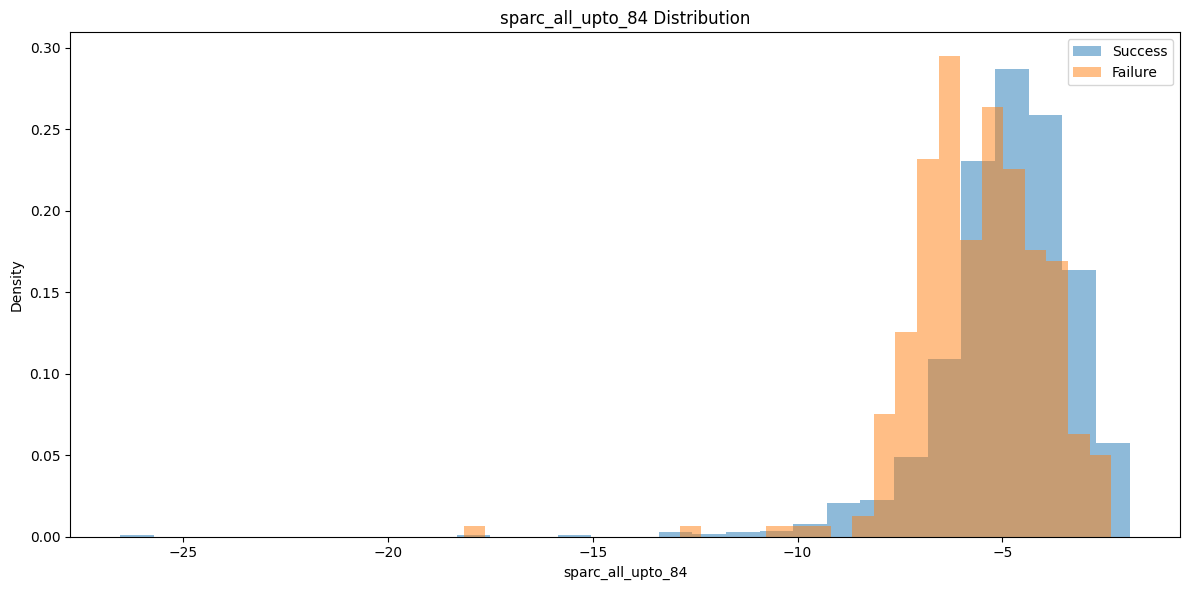

In [9]:
analyzer.plot_metric_histogram_by_success("sparc_all_upto_failure", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws4_upto_7_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws3_upto_7_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws2_upto_7_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_knot_ws4_upto_7_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("delta_eval_fn_upto_7_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_all_upto_84", figsize=(12, 6))

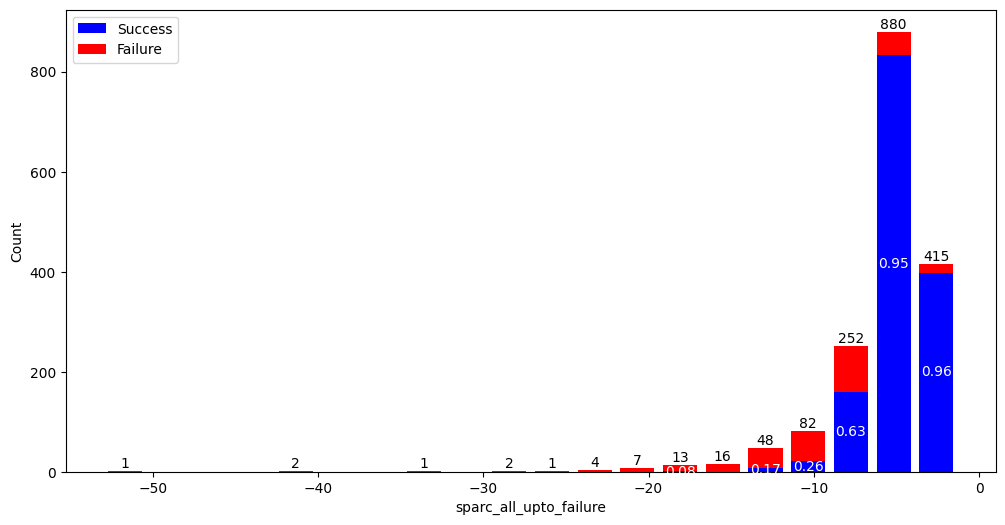

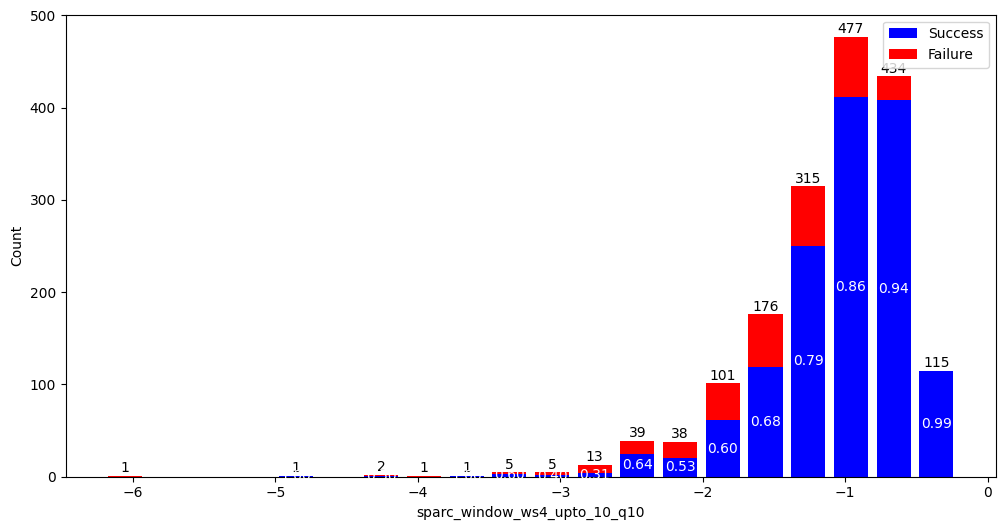

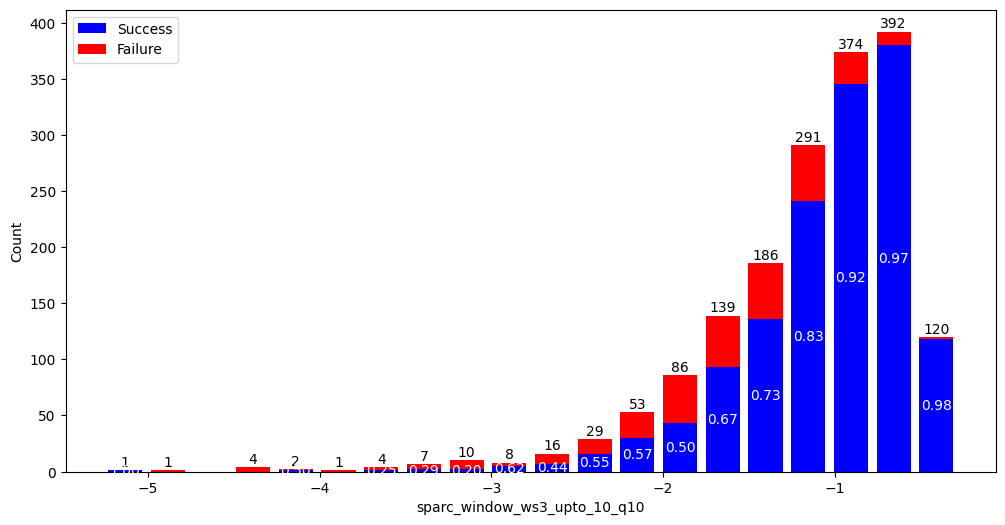

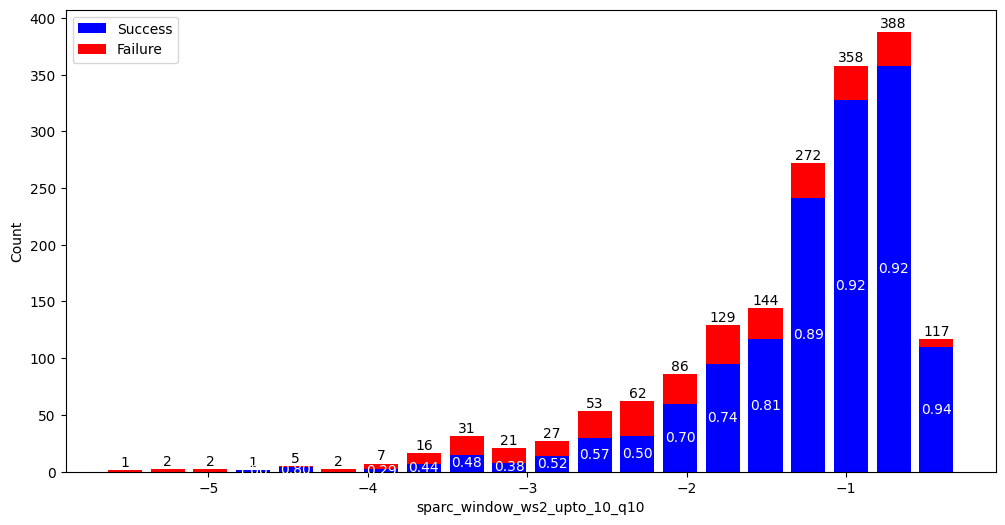

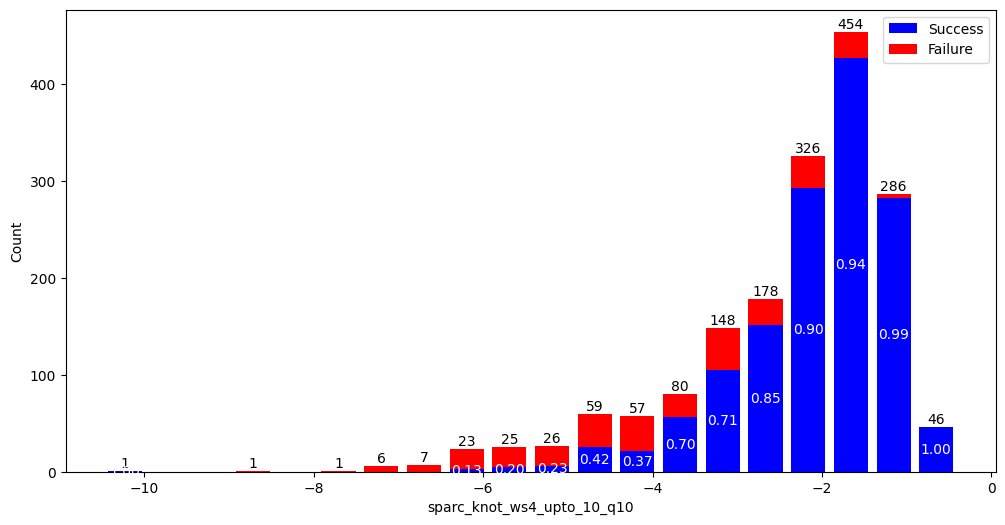

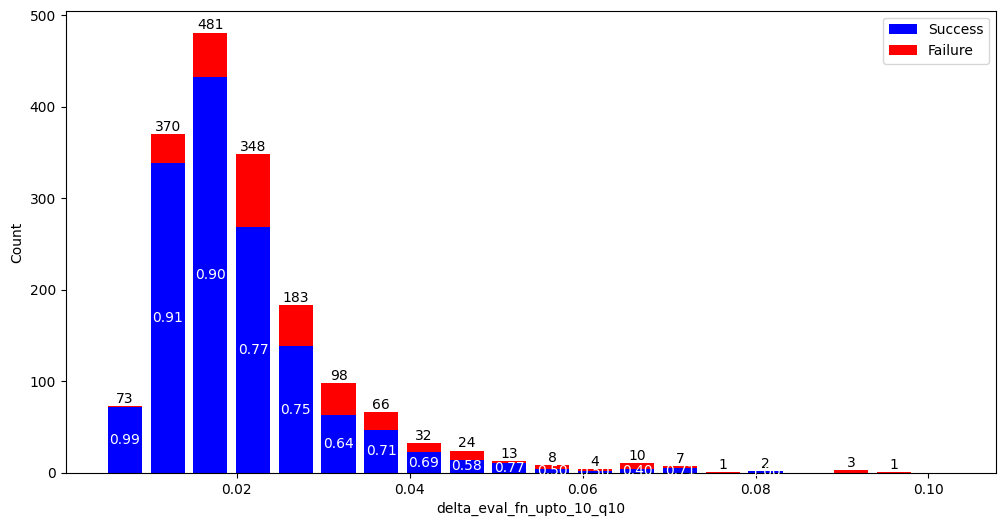

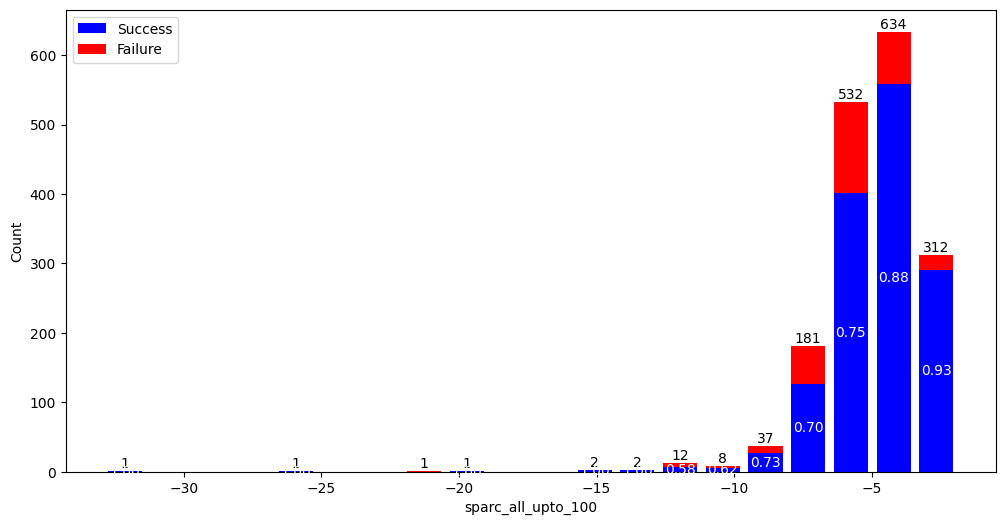

In [10]:
analyzer.plot_stacked_success_histogram("sparc_all_upto_failure", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws4_upto_10_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws3_upto_10_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_window_ws2_upto_10_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_knot_ws4_upto_10_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("delta_eval_fn_upto_10_q10", figsize=(12, 6), bins=20)
analyzer.plot_stacked_success_histogram("sparc_all_upto_100", figsize=(12, 6), bins=20)

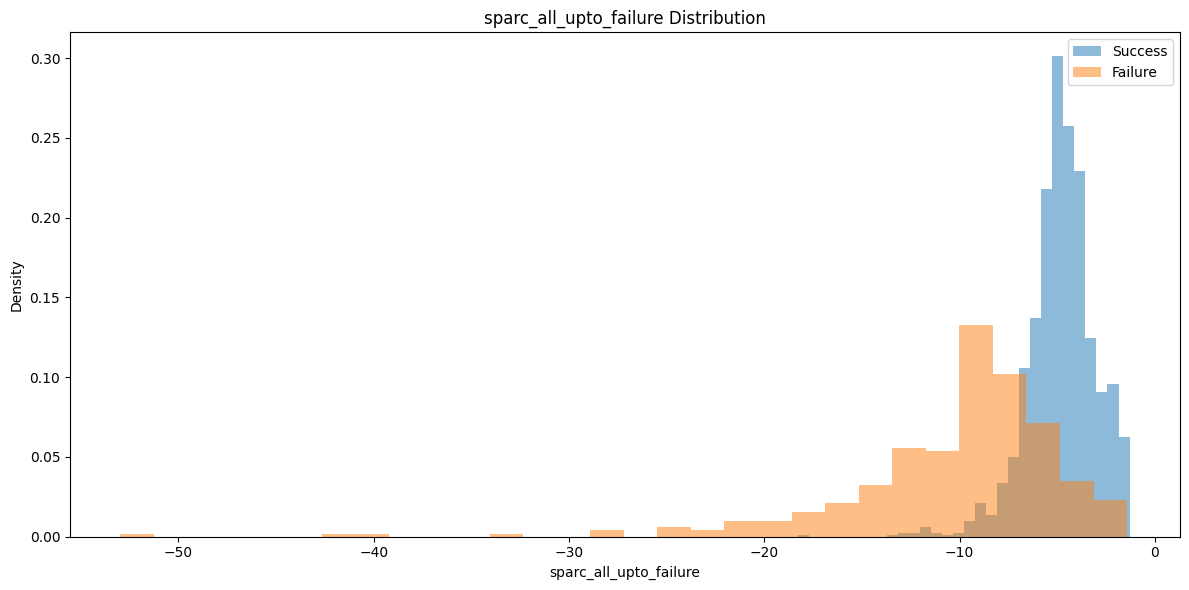

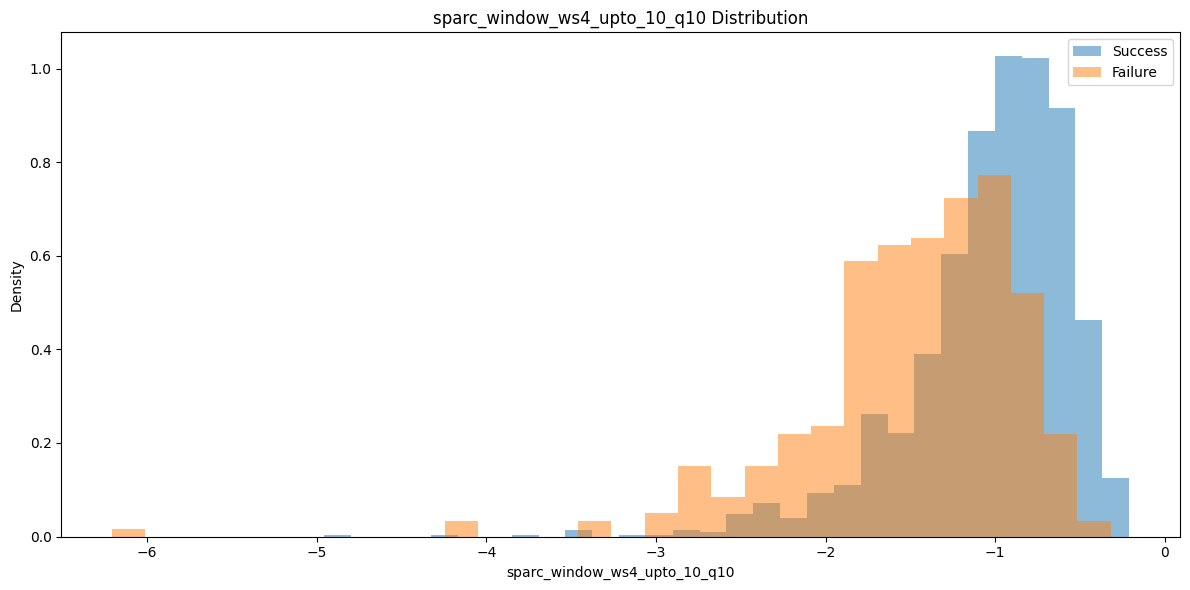

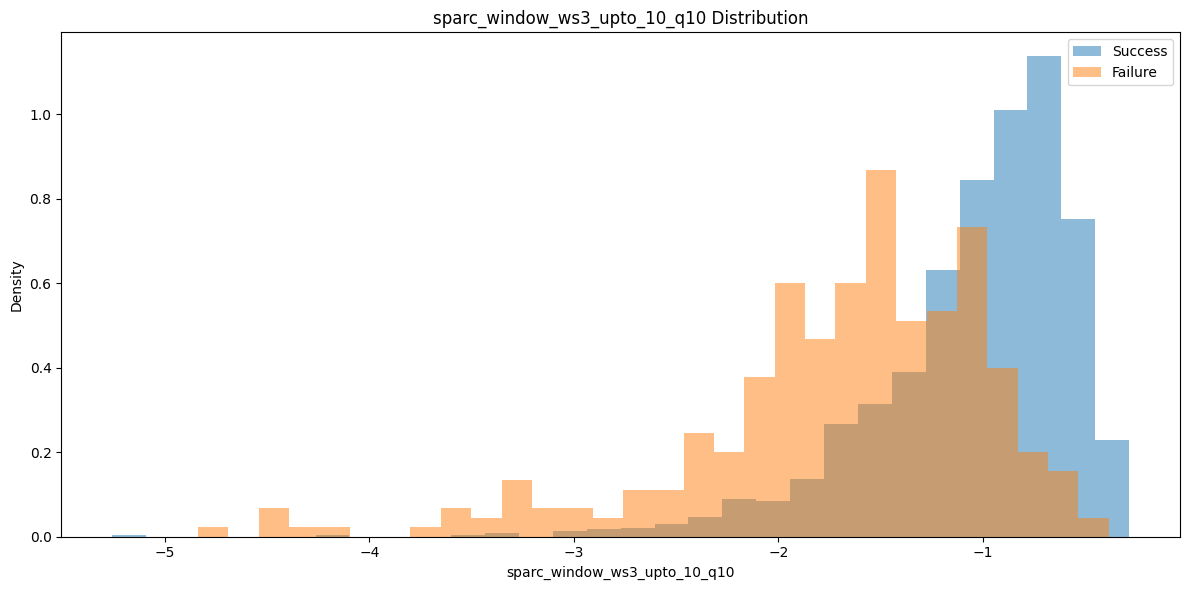

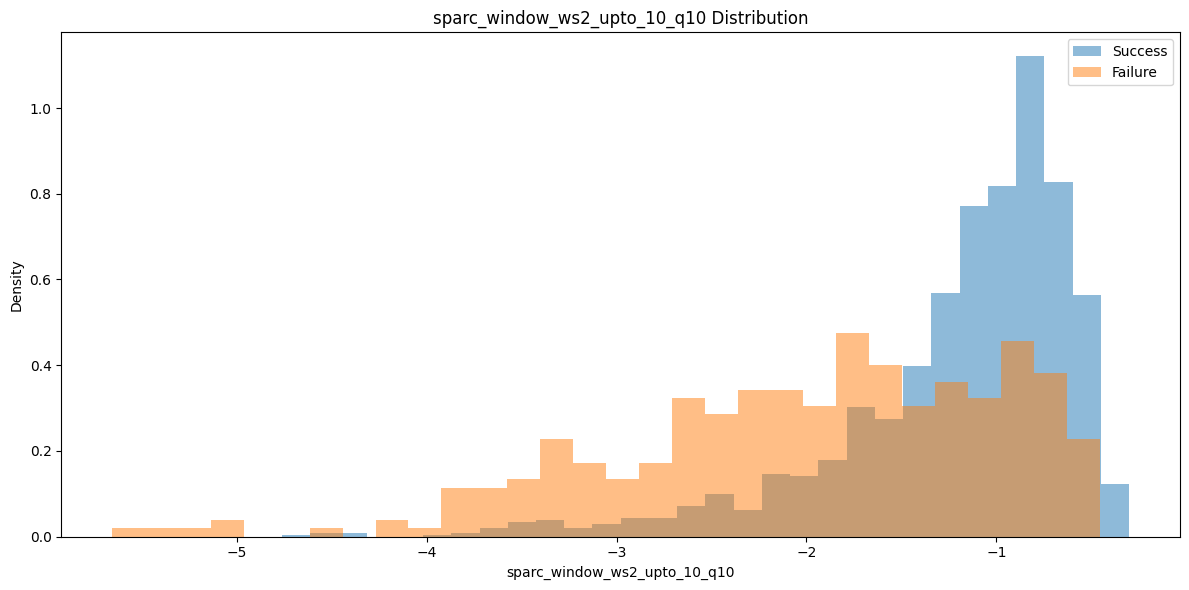

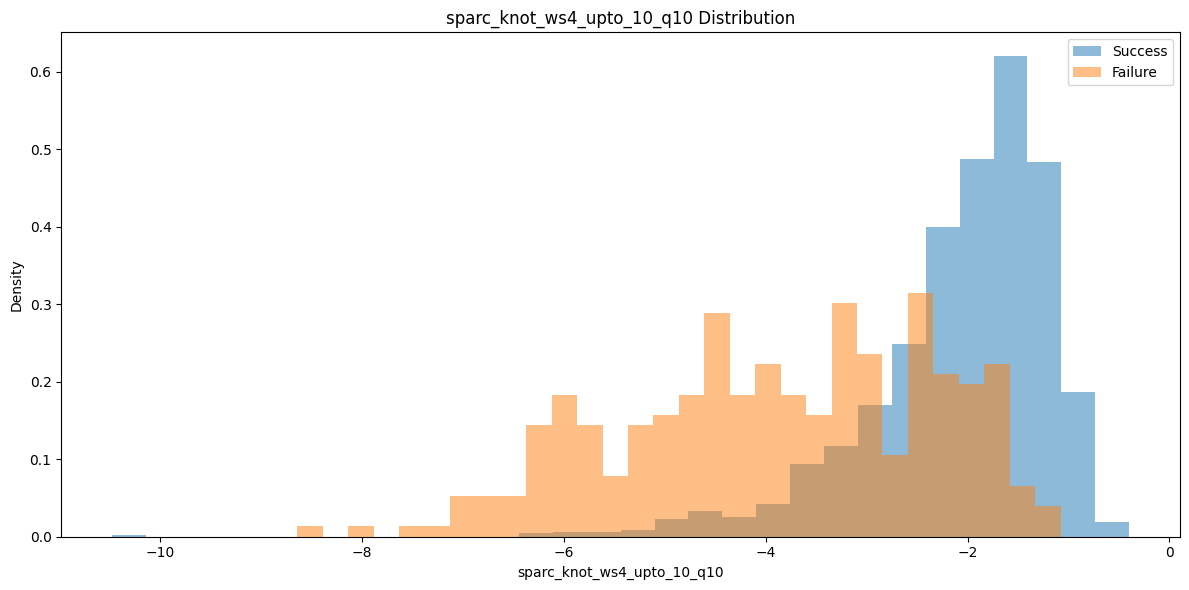

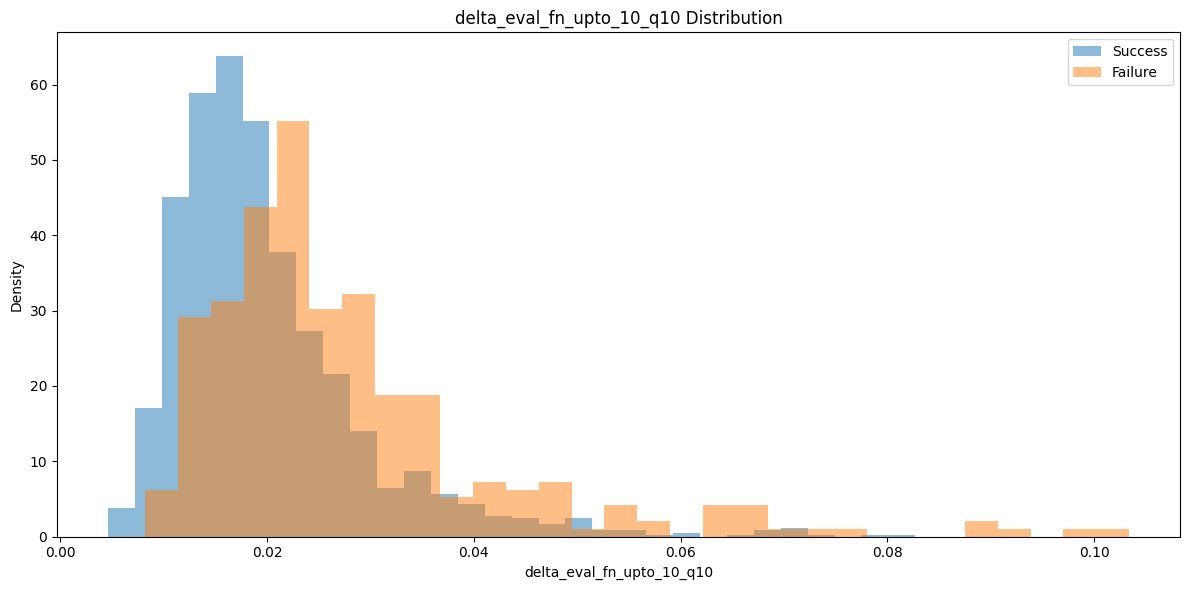

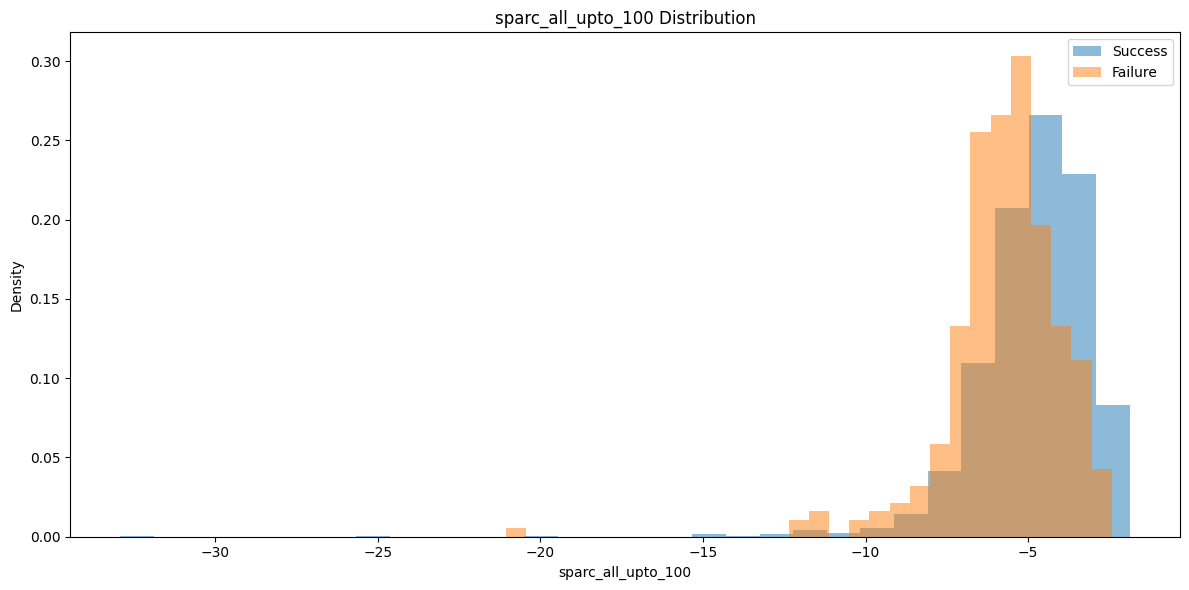

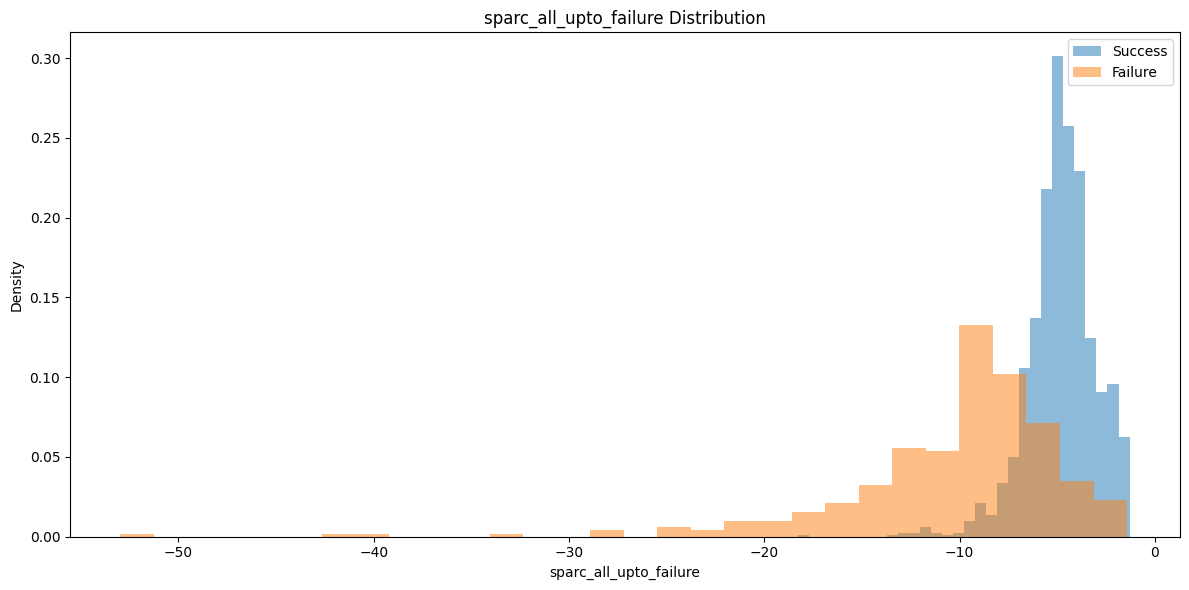

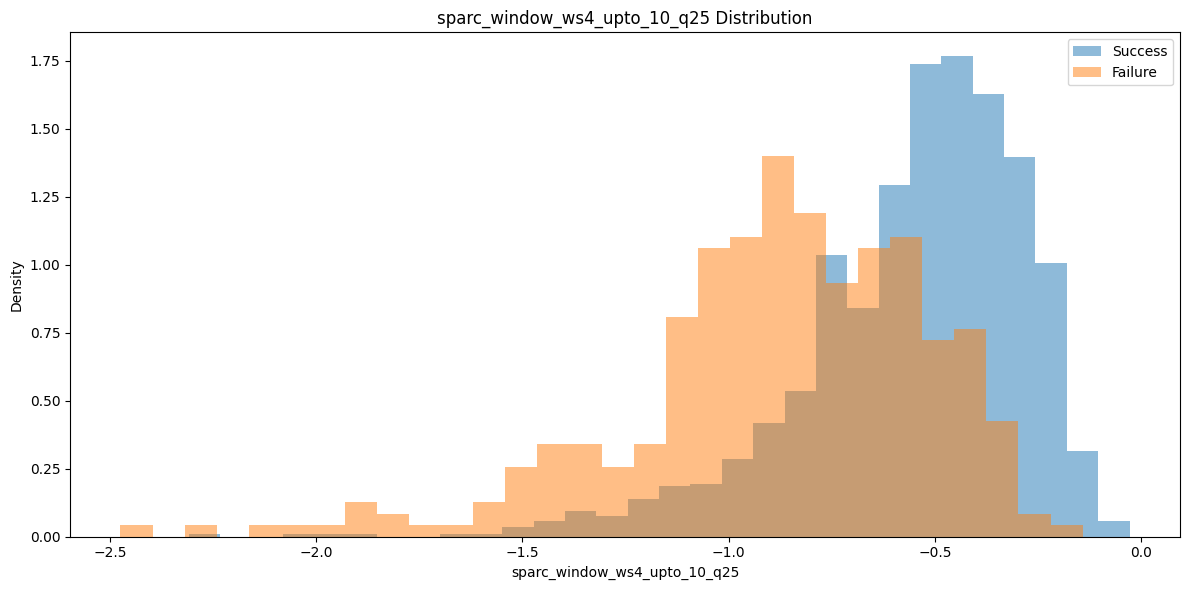

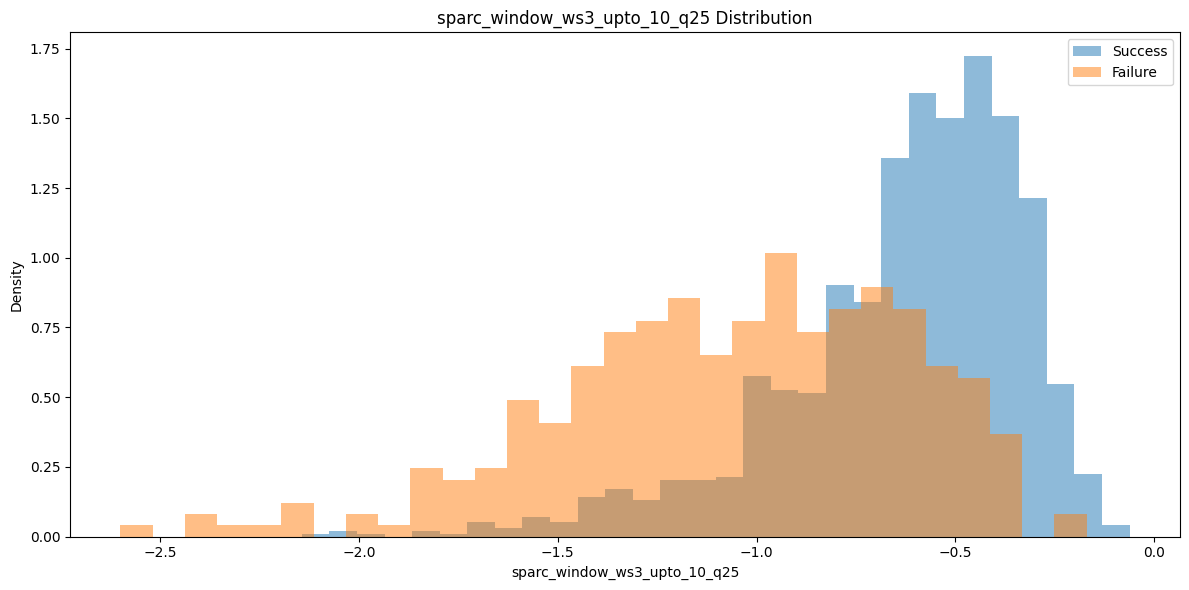

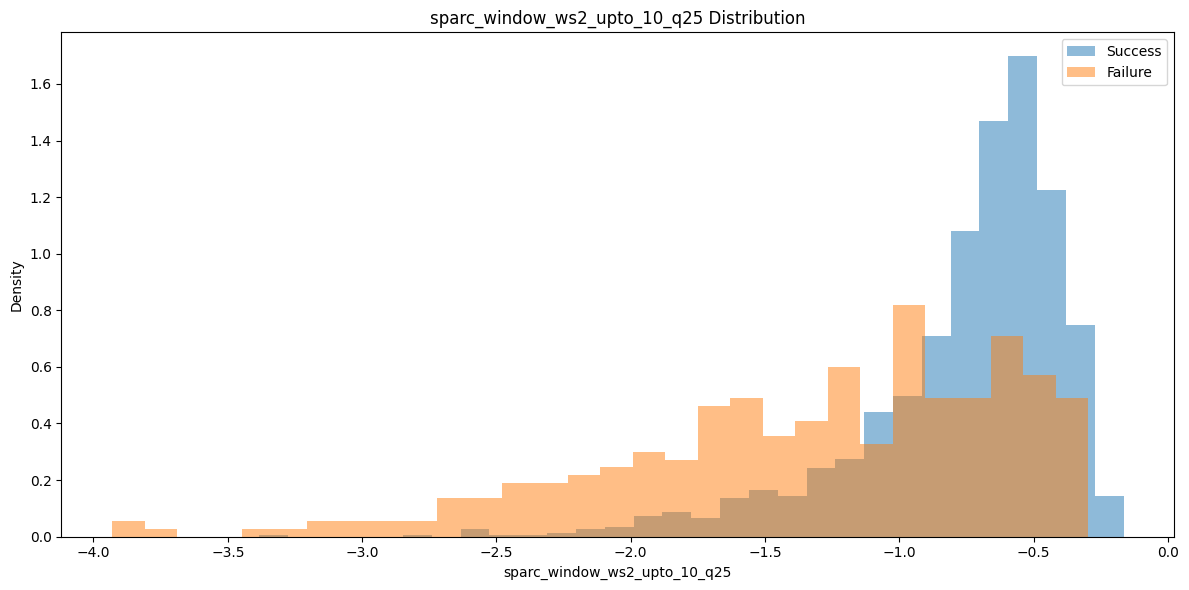

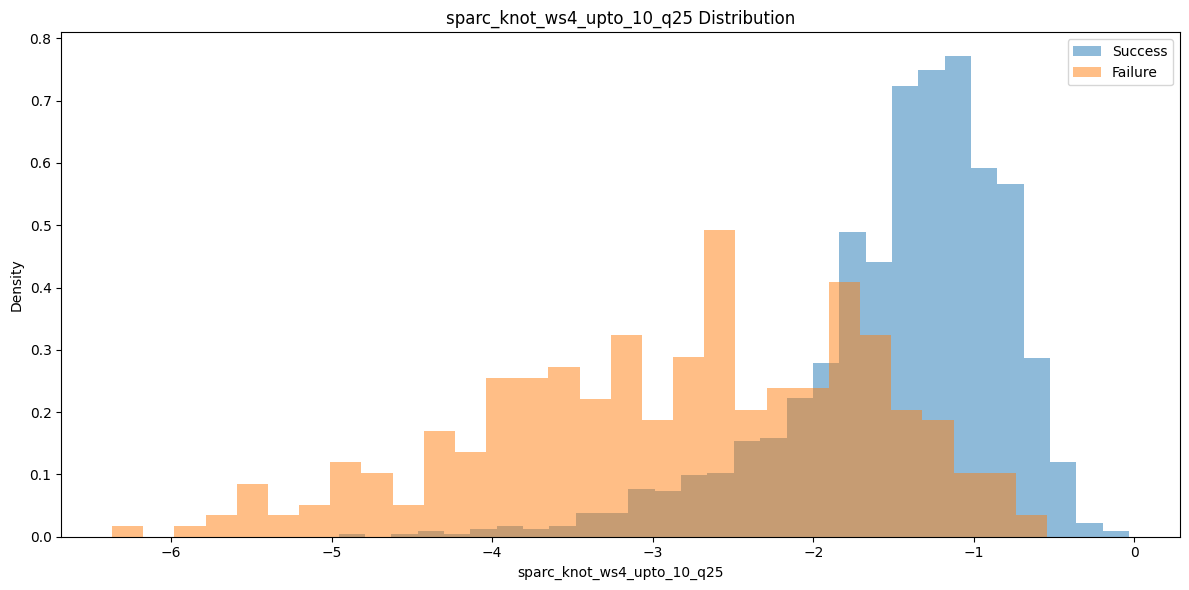

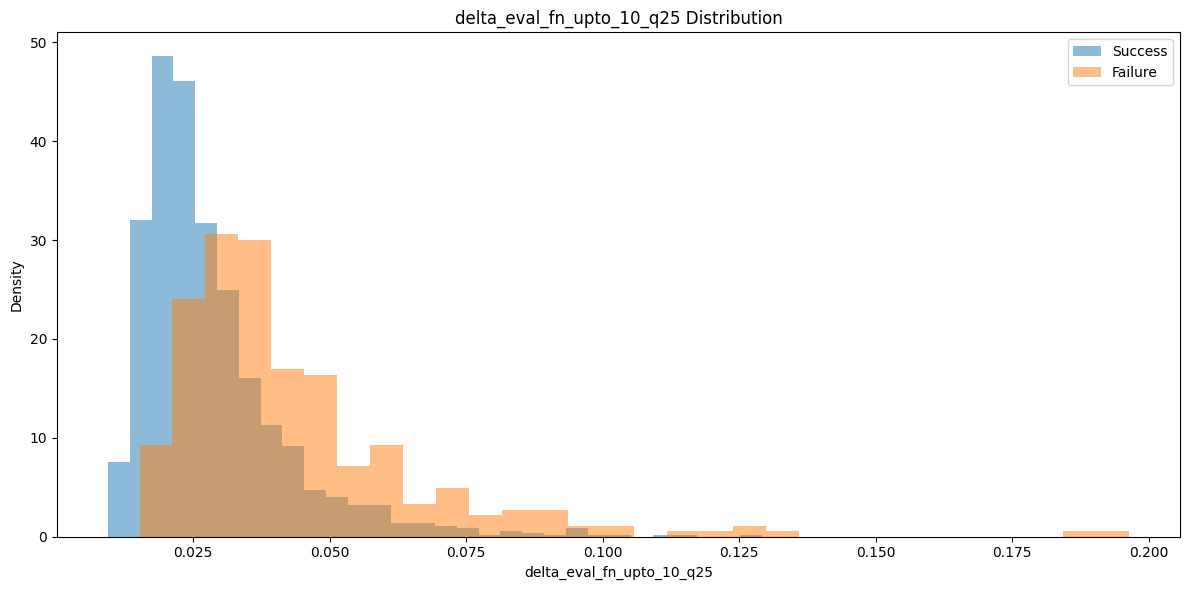

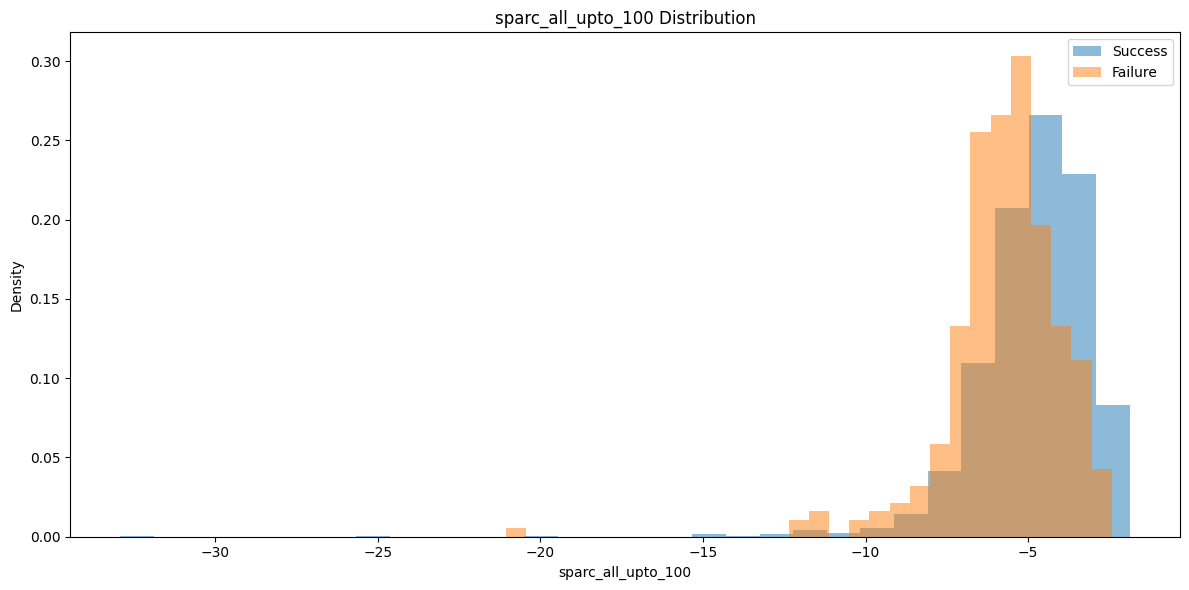

In [11]:
analyzer.plot_metric_histogram_by_success("sparc_all_upto_failure", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws4_upto_10_q10", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws3_upto_10_q10", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws2_upto_10_q10", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_knot_ws4_upto_10_q10", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("delta_eval_fn_upto_10_q10", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_all_upto_100", figsize=(12, 6))

analyzer.plot_metric_histogram_by_success("sparc_all_upto_failure", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws4_upto_10_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws3_upto_10_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_window_ws2_upto_10_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_knot_ws4_upto_10_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("delta_eval_fn_upto_10_q25", figsize=(12, 6))
analyzer.plot_metric_histogram_by_success("sparc_all_upto_100", figsize=(12, 6))

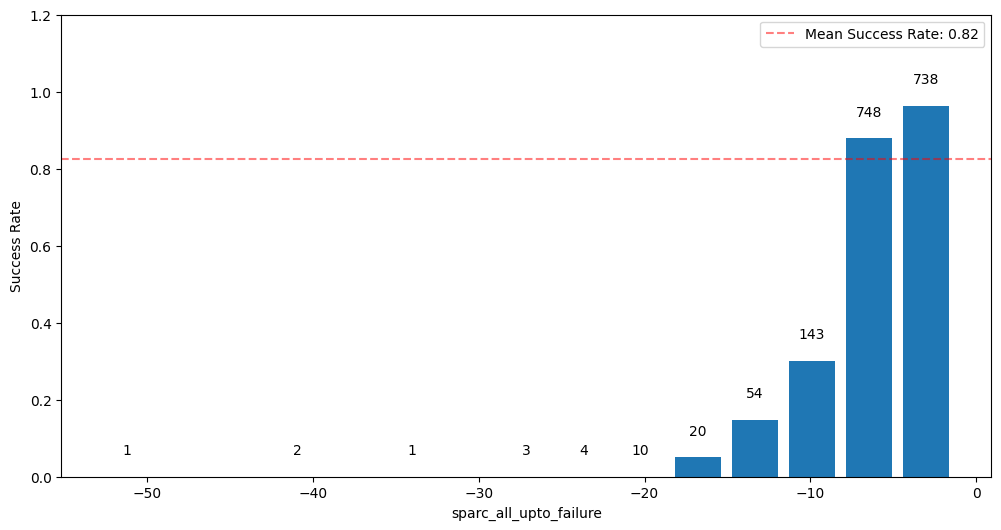

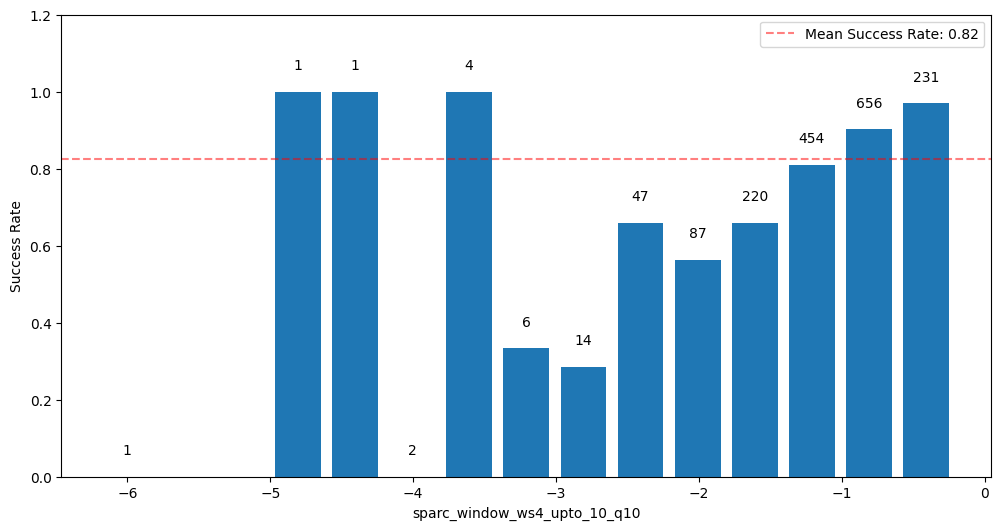

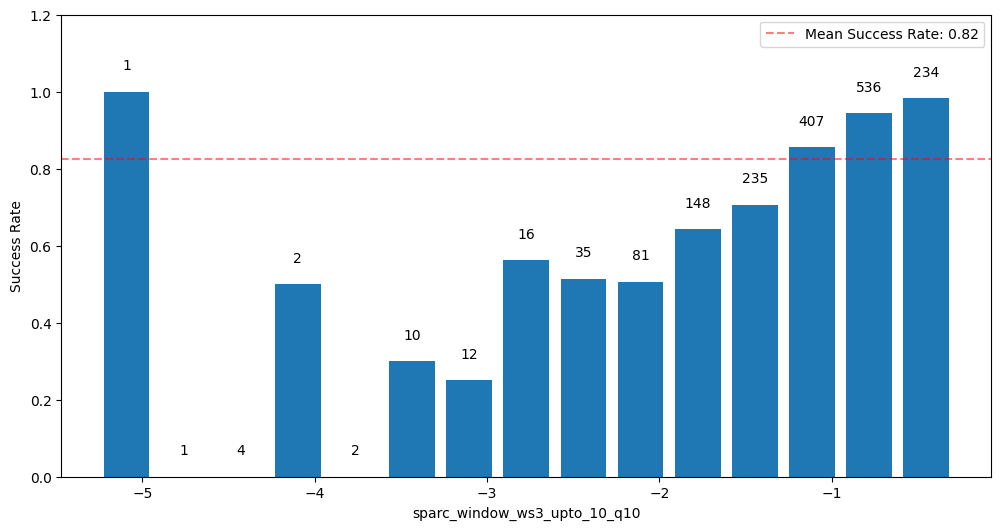

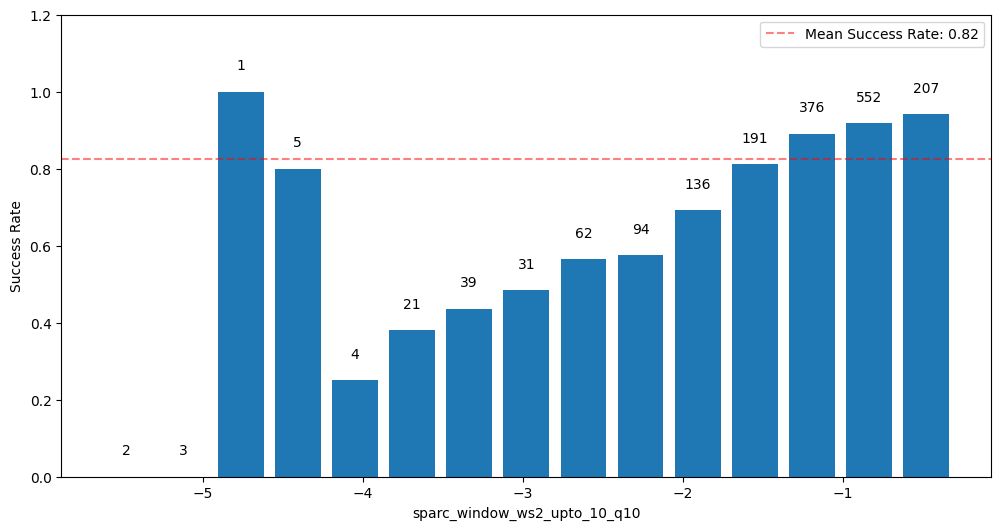

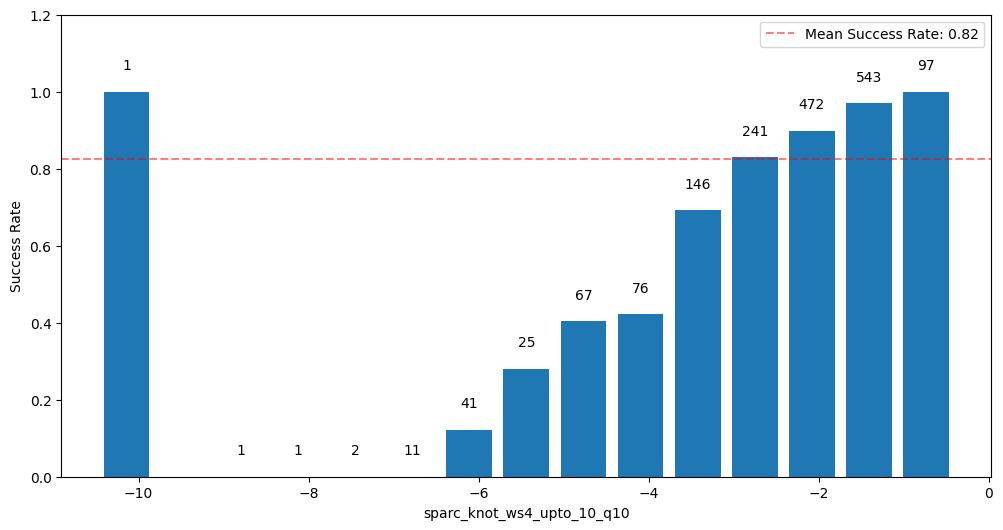

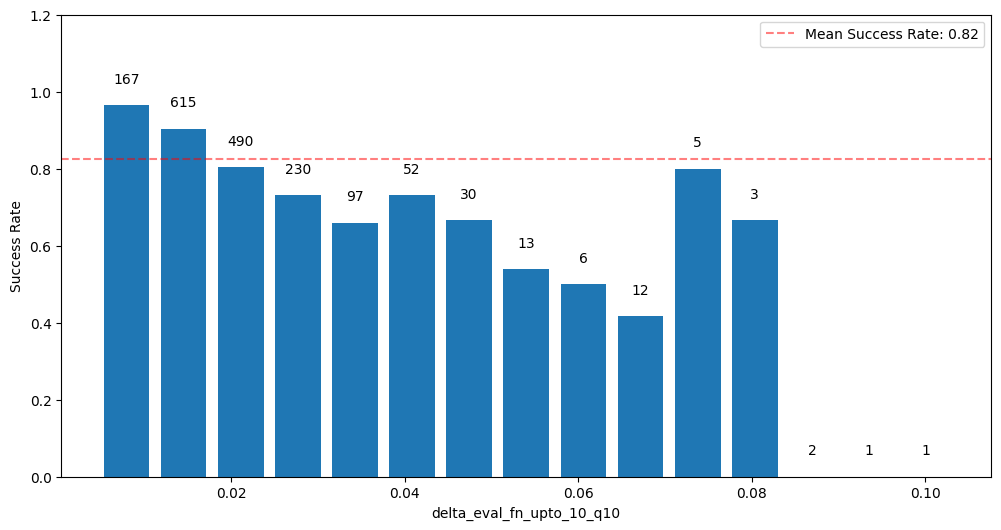

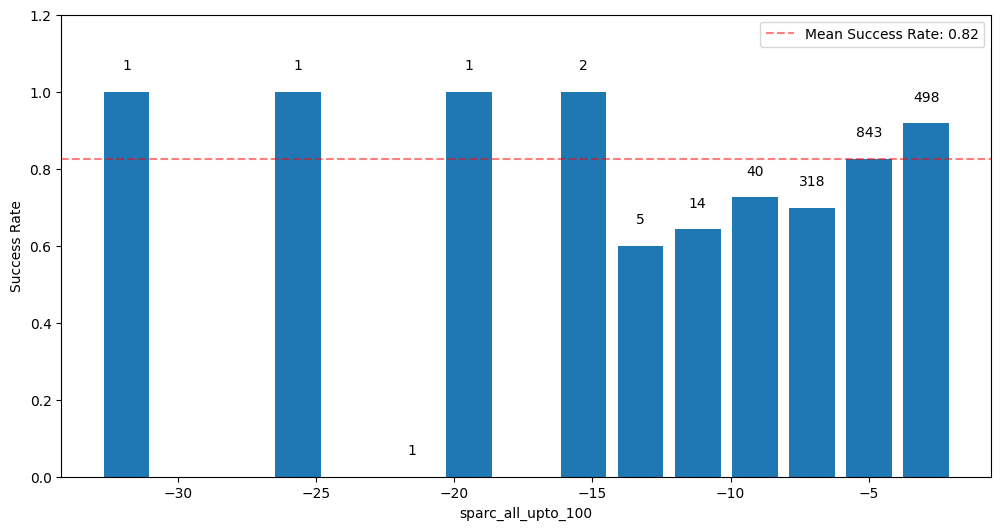

In [12]:
analyzer.plot_success_rate_per_bin("sparc_all_upto_failure", figsize=(12, 6))
analyzer.plot_success_rate_per_bin("sparc_window_ws4_upto_10_q10", figsize=(12, 6))
analyzer.plot_success_rate_per_bin("sparc_window_ws3_upto_10_q10", figsize=(12, 6))
analyzer.plot_success_rate_per_bin("sparc_window_ws2_upto_10_q10", figsize=(12, 6))
analyzer.plot_success_rate_per_bin("sparc_knot_ws4_upto_10_q10", figsize=(12, 6))
analyzer.plot_success_rate_per_bin("delta_eval_fn_upto_10_q10", figsize=(12, 6))
analyzer.plot_success_rate_per_bin("sparc_all_upto_100", figsize=(12, 6))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


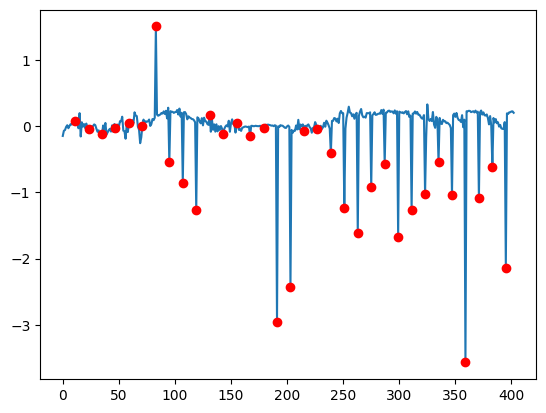

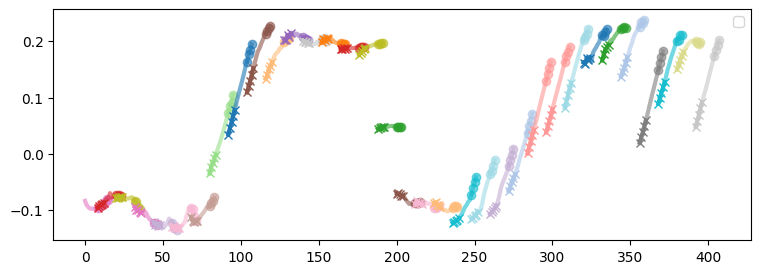

In [13]:
demo_file = pkl_utils.load_result_pkl_file(pkl_utils.get_result_pkl_files(result_dir, filter="bl")[12])["rollouts"]["demo_19"]
velocity = demo_utils.get_end_effector_velocity(demo_file, type="cmd")
speed = np.linalg.norm(velocity, axis=-1)
Ta = 12
t_eval = np.arange(0, velocity.shape[0]-Ta, Ta) + Ta - 1
plt.plot(np.arange(velocity.shape[0]), velocity[:, 0])
plt.plot(t_eval, velocity[t_eval, 0], 'ro')
_ = plot_utils.plot_predictions(demo_file, action_idx=0)


### Prediction Consistency Analysis

In [14]:

video_path = os.path.join(robomimic.__path__[0], "smoothness_analysis.mp4")
amp_th = 0.05
dt = 0.05
n_skip = 3
type = "cmd"

results_to_animate = []
N_timestep = demo_file_bl["num_executed_actions"]
print(N_timestep)
t_end_vec = np.arange(10, N_timestep, 5)
for t_end in t_end_vec:
    results_eef = SmoothnessMetrics.analyze_sparc_progression(
        demo_file_bl,
        velocity_fn="eef_velocity",
        dt=dt,
        type=type,
        n_skip=n_skip,
        amp_th=amp_th,
        t_end=t_end if t_end < N_timestep else None
    )
    results_eef["success"] = 1.0
    
    results_to_animate.append([results_eef])

plot_utils.plot_smoothness_video(results_to_animate, save_path=video_path)
display(Video(video_path, embed=True))


NameError: name 'demo_file_bl' is not defined

### SPARC Analysis

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


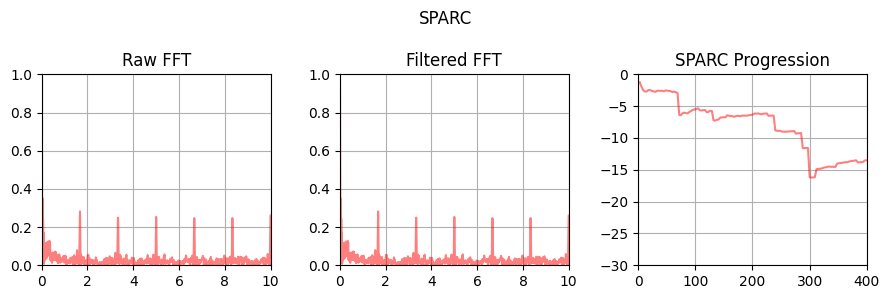

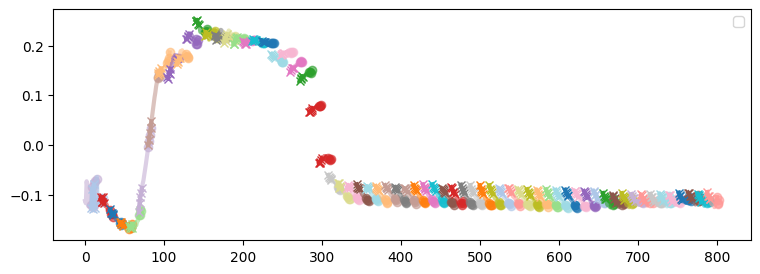

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


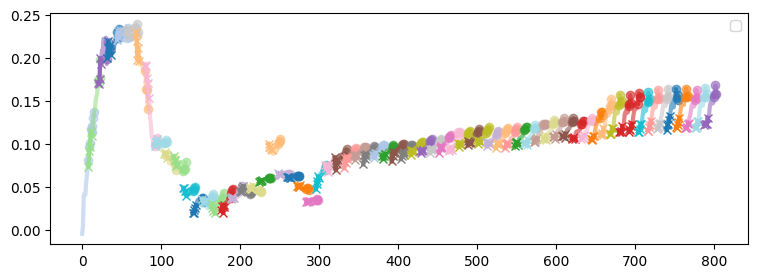

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


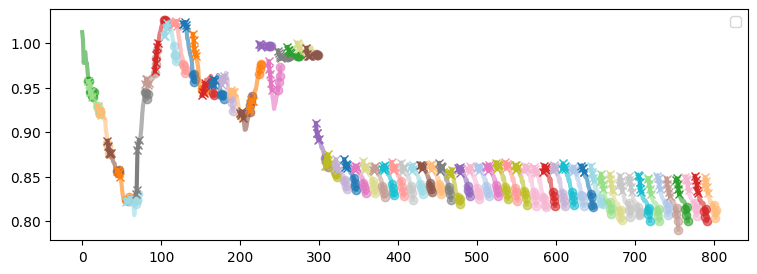

In [188]:
# Single demo analysis
demo_idx = 36
demo_file_bl   = data_baseline["rollouts"][f"demo_{demo_idx}"]
smoothness_results = SmoothnessMetrics.analyze_sparc_progression(
    demo_file_bl,
    velocity_fn="eef_velocity",
    dt=dt,
    type=type,
    n_skip=n_skip,
    amp_th=amp_th
)
smoothness_results["success"] = data_baseline["stats"]["Success_Rate"][demo_idx]
plot_utils.plot_smoothness_analysis([smoothness_results], title="SPARC", figsize=(9, 3), ylim_smoothness=(-30, 0))

_ = plot_utils.plot_predictions(demo_file_bl, action_idx=0)
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=1)
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=2)

# cutoff_freq = 2
# movements = demo_utils.get_end_effector_velocity(demo_file_bl, type="cmd")
# speed = np.linalg.norm(movements, axis=-1)

# sum_mag_list = []
# max_mag_list = []
# sparc_list = []
# for i in range(demo_file_bl["num_inferences"]):
#     speed_i = speed[Ta*i:Ta*(i+1)]
#     full_sparc, raw_fft, filtered_fft = SmoothnessMetrics.sparc(speed_i, dt=dt, padlevel=4, fc=20.0, amp_th=0.05, return_data=True)
#     mag = filtered_fft[1][filtered_fft[0] > cutoff_freq]
#     sum_mag_list.append(mag.sum())
#     max_mag_list.append(mag.max())
#     sparc_list.append(full_sparc)

# # plt.plot(np.arange(demo_file_bl["num_inferences"])*Ta, sum_mag_list, color="red")
# plt.plot(np.arange(demo_file_bl["num_inferences"])*Ta, sparc_list, color="green")
# plt.figure()
# plt.plot(np.arange(demo_file_bl["num_inferences"])*Ta, max_mag_list, color="blue")
# plt.ylim(0, 1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


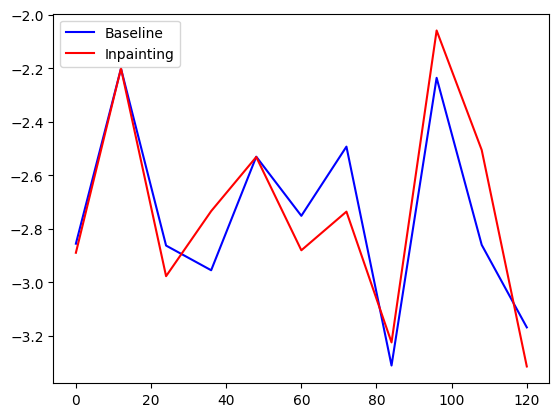

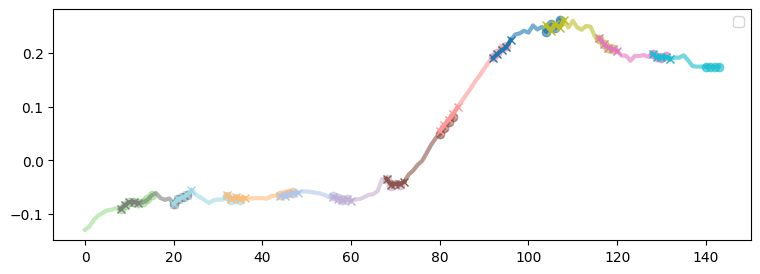

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


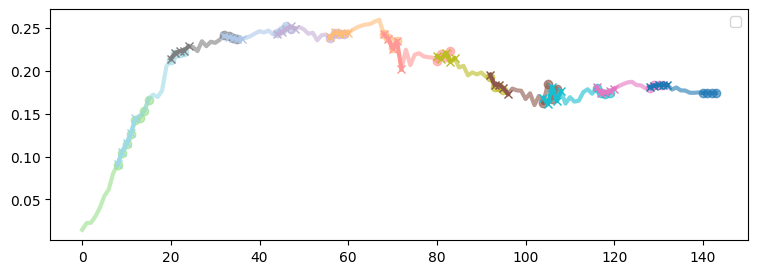

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


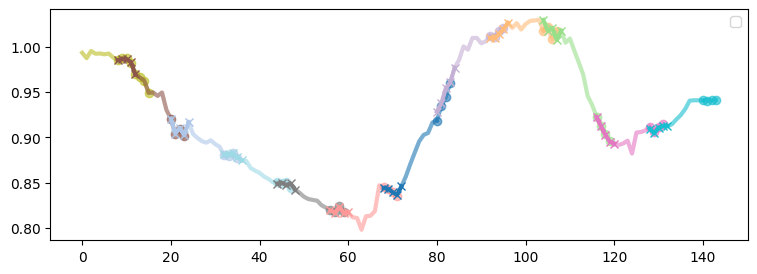

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


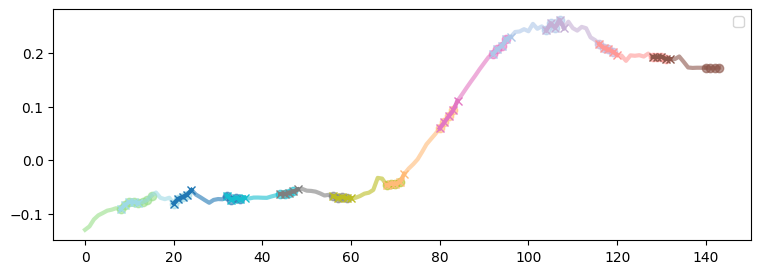

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


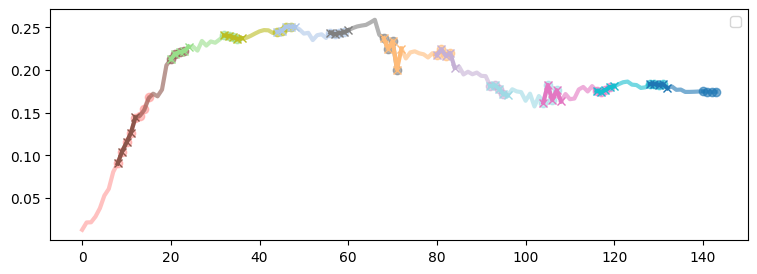

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


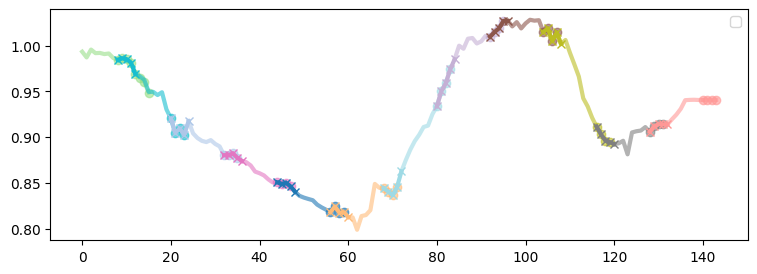

In [219]:
demo_idx = 17
demo_file_bl   = data_baseline["rollouts"][f"demo_{demo_idx}"]
demo_file_inp  = data_inp["rollouts"][f"demo_{demo_idx}"]

demos = [demo_file_bl, demo_file_inp]
colors = ["blue", "red"]

for idx, demo in enumerate(demos):
    sparc_list = []

    movements = demo_utils.get_end_effector_velocity(demo, type="cmd")
    speed = np.linalg.norm(movements, axis=-1)

    for i in range(demo["num_inferences"]):
        if i > 0:
            start_idx = int(Ta*i-Ta)
            end_idx = int(Ta*i+Ta)
            speed_i = speed[start_idx:end_idx]
            
            full_sparc, raw_fft, filtered_fft = SmoothnessMetrics.sparc(speed_i, dt=dt, padlevel=4, fc=20.0, amp_th=0.05, return_data=True)
            sparc_list.append(full_sparc)

    plt.plot(np.arange(demo["num_inferences"]-1)*Ta, sparc_list, color=colors[idx])
plt.legend(["Baseline", "Inpainting"])

_ = plot_utils.plot_predictions(demo_file_bl, action_idx=0)
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=1)
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=2)

_ = plot_utils.plot_predictions(demo_file_inp, action_idx=0)
_ = plot_utils.plot_predictions(demo_file_inp, action_idx=1)
_ = plot_utils.plot_predictions(demo_file_inp, action_idx=2)

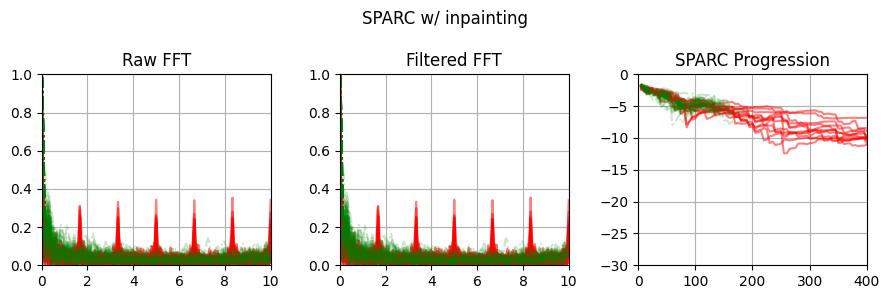

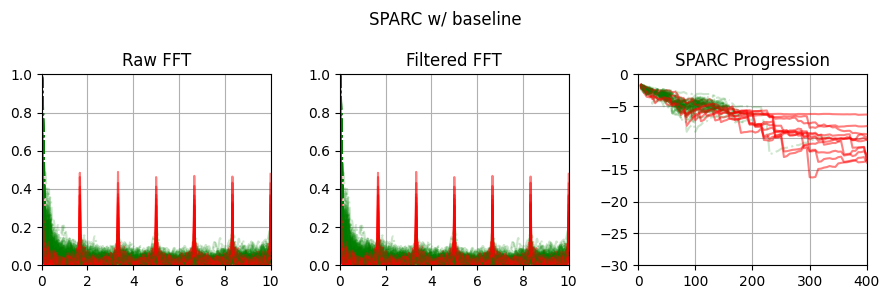

In [24]:

# Multiple demo analysis
result_idx = 0
data = pkl_utils.load_result_pkl_file(pkl_files_inp[result_idx])

analysis_fn = lambda demo: SmoothnessMetrics.analyze_sparc_progression(demo, velocity_fn="eef_velocity", dt=dt, type="cmd", n_skip=n_skip, amp_th=amp_th)
results_eef = stat_utils.analyze_pkl_data(
    data,
    analysis_fn,
    [stat_utils.label_success]
)
plot_utils.plot_smoothness_analysis(results_eef, title="SPARC w/ inpainting", figsize=(9, 3), ylim_smoothness=(-30, 0))

data = pkl_utils.load_result_pkl_file(pkl_files_baseline[result_idx])
results_eef = stat_utils.analyze_pkl_data(
    data,
    analysis_fn,
    [stat_utils.label_success]
)
plot_utils.plot_smoothness_analysis(results_eef, title="SPARC w/ baseline", figsize=(9, 3), ylim_smoothness=(-30, 0))

## Video Analysis

In [10]:
pkl_path = "/home/wjung85/Repo/projects/FastIL/logs/hparam/square_image_action_horizon_16_inp_t_ts_40_eta_1_nres_1_iter_0_2025-01-08 14:01:21.391115.pkl"

In [ ]:
# Get video path by replacing .pkl extension with .mp4
video_dir = "/home/wjung85/Repo/projects/FastIL/videos/hparam"
# Extract hyperparameters from pkl filename
pkl_basename = os.path.basename(pkl_path)
hparams = pkl_basename.split("_")
# Get relevant hyperparameters: image_action_horizon, inp_t_ts, eta, nres, iter
video_pattern = f"square_image_action_horizon_{hparams[4]}_inp_t_ts_{hparams[8]}_eta_{hparams[10]}_nres_{hparams[12]}_iter_{hparams[14]}"
# Find matching video file
matching_videos = [f for f in os.listdir(video_dir) if f.startswith(video_pattern) and f.endswith(".mp4")]
video_path = os.path.join(video_dir, matching_videos[0]) if matching_videos else None

# Check if video file exists before trying to display it
if not os.path.exists(video_path):
    print(f"Warning: Video file not found at {video_path}")

else:
    # Display the video
    print(f"Playing video from: {video_path}")
    display(Video(video_path, embed=True))

# import subprocess
# output_file = f"/tmp/eval/{video_path.split('/')[-1]}"
# subprocess.run([
#     "ffmpeg", "-y", "-i", video_path, "-ss", "00:00:00", "-to", "00:00:01", 
#     "-c", "copy", output_file
# ], check=True)
# display(Video(output_file, embed=True))

In [68]:
def display_video_segment(data, video_path, demo_idx, video_fps = 50):
    import subprocess
    demo_length_list = np.array([len(data["rollouts"][demo_idx]["executed_actions"]) for demo_idx in data["rollouts"].keys()])
    start_time =np.sum(demo_length_list[:demo_idx])/video_fps if demo_idx > 0 else 0
    end_time = np.sum(demo_length_list[:demo_idx+1])/video_fps
    
    output_file = f"/tmp/eval/{video_path.split('/')[-1]}"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    print(start_time, end_time)
    
    start_time = f"00:{int(start_time/60):02d}:{int(start_time%60):02d}"
    end_time = f"00:{int(end_time/60):02d}:{int(end_time%60):02d}"
    
    print(start_time, end_time)
    
    subprocess.run([
        "ffmpeg", "-y", "-i", video_path, "-ss", start_time, "-to", end_time, 
        "-c", "copy", output_file
    ], check=True)
    return Video(output_file, embed=True)

In [ ]:
video = display_video_segment(data, video_path, 39)

In [ ]:
video.filename

In [ ]:
query_demo_idx = 35
total_demo_len = 0
video_fps      = 4
demo_length_list = np.array([len(data["rollouts"][demo_idx]["executed_actions"]) for demo_idx in data["rollouts"].keys()])

query_demo_len = total_demo_len / video_fps

display(Video(video_path, embed=True, start_time=np.cumsum(demo_length_list[:query_demo_idx]), end_time=np.cumsum(demo_length_list[:query_demo_idx+1])))

### Test the numerical difference between cmd and real

(-2.0, 2.0)

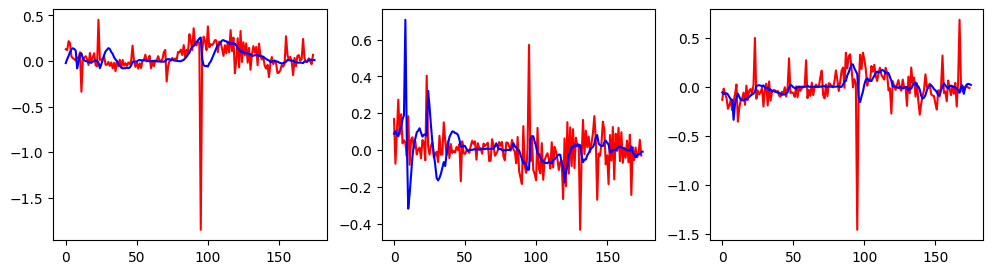

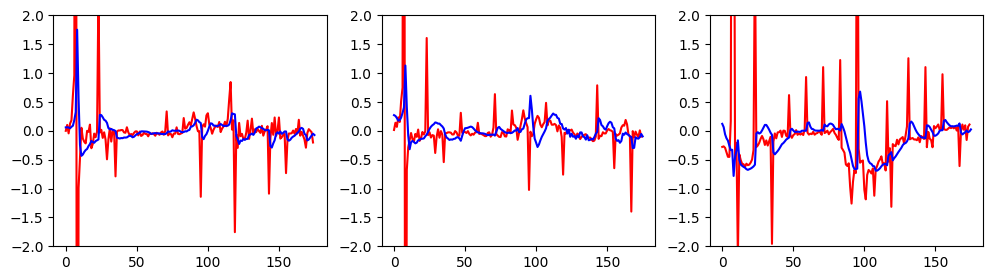

In [10]:

##### user input #######
result_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug"
pkl_files_baseline = pkl_utils.get_result_pkl_files(result_dir, filter="bl")
result_idx = 0
demo_idx   = 0
########################

data_baseline  = pkl_utils.load_result_pkl_file(pkl_files_baseline[result_idx])
demo_file_bl   = data_baseline["rollouts"][f"demo_{demo_idx}"]

vel_cmd = demo_utils.get_end_effector_velocity(demo_file_bl, type="cmd")
vel_real = demo_utils.get_end_effector_velocity(demo_file_bl, type="real")

angvel_cmd = demo_utils.get_end_effector_angular_velocity(demo_file_bl, type="cmd")
angvel_real = demo_utils.get_end_effector_angular_velocity(demo_file_bl, type="real")

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.plot(np.arange(demo_file_bl["num_executed_actions"]-1), vel_cmd[:, 0], color="red")
plt.plot(np.arange(demo_file_bl["num_executed_actions"]), vel_real[:, 0], color="blue")
plt.subplot(1, 3, 2)
plt.plot(np.arange(demo_file_bl["num_executed_actions"]-1), vel_cmd[:, 1], color="red")
plt.plot(np.arange(demo_file_bl["num_executed_actions"]), vel_real[:, 1], color="blue")
plt.subplot(1, 3, 3)
plt.plot(np.arange(demo_file_bl["num_executed_actions"]-1), vel_cmd[:, 2], color="red")
plt.plot(np.arange(demo_file_bl["num_executed_actions"]), vel_real[:, 2], color="blue")

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.plot(np.arange(demo_file_bl["num_executed_actions"]-1), angvel_cmd[:, 0], color="red")
plt.plot(np.arange(demo_file_bl["num_executed_actions"]), angvel_real[:, 0], color="blue")
plt.ylim(-2, 2)
plt.subplot(1, 3, 2)
plt.plot(np.arange(demo_file_bl["num_executed_actions"]-1), angvel_cmd[:, 1], color="red")
plt.plot(np.arange(demo_file_bl["num_executed_actions"]), angvel_real[:, 1], color="blue")
plt.ylim(-2, 2)
plt.subplot(1, 3, 3)
plt.plot(np.arange(demo_file_bl["num_executed_actions"]-1), angvel_cmd[:, 2], color="red")
plt.plot(np.arange(demo_file_bl["num_executed_actions"]), angvel_real[:, 2], color="blue")
plt.ylim(-2, 2)

In [ ]:
(result_idx, demo_idx) = (0, 19)
data_baseline  = pkl_utils.load_result_pkl_file(pkl_files_baseline[result_idx])
demo_file_bl   = data_baseline["rollouts"][f"demo_{demo_idx}"]


type = "cmd"
padlevel = 4
fc = 20.0
amp_th = 0.05

Ta = demo_utils.get_Ta(demo_file_bl)
dt = 1/demo_file_bl["kwargs"]["fast_control_freq"]
num_inferences = demo_file_bl["num_inferences"]
vel = demo_utils.get_end_effector_velocity(demo_file_bl, type=type)
speed = np.linalg.norm(vel, axis=-1)

sparc_delta_list = []
sparc_next_list = []
sparc_curr_list = []
for i in range(num_inferences-1):
    speed_i_next = speed[Ta*i:Ta*(i+2)]
    speed_i_curr = speed[Ta*i:Ta*(i+1)]
    
    sparc_i_next, raw_fft_i_next, filtered_fft_i_next = SmoothnessMetrics.sparc(speed_i_next, dt = dt, padlevel=padlevel, fc=fc, amp_th=amp_th, return_data=True)
    sparc_i_curr, raw_fft_i_curr, filtered_fft_i_curr = SmoothnessMetrics.sparc(speed_i_curr, dt = dt, padlevel=padlevel, fc=fc, amp_th=amp_th, return_data=True)

    sparc_i_delta = sparc_i_next - sparc_i_curr

    sparc_next_list.append(sparc_i_next)
    sparc_curr_list.append(sparc_i_curr)
    sparc_delta_list.append(sparc_i_delta)
    # plt.plot(raw_fft_i_next[0], raw_fft_i_next[1], color="red")
    # plt.plot(filtered_fft_i_next[0], filtered_fft_i_next[1], color="blue")
    # plt.plot(raw_fft_i_curr[0], raw_fft_i_curr[1], color="red")
    # plt.plot(filtered_fft_i_curr[0], filtered_fft_i_curr[1], color="blue")

print(data_baseline["stats"]["Success_Rate"][demo_idx])

plt.plot(np.arange(num_inferences-1)*Ta, sparc_delta_list, color="red")
plt.plot(np.arange(num_inferences-1)*Ta, sparc_next_list, color="blue")
plt.plot(np.arange(num_inferences-1)*Ta, sparc_curr_list, color="green")
plt.legend(["SPARC Delta", "SPARC Next", "SPARC Current"])
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=0)
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=1)
_ = plot_utils.plot_predictions(demo_file_bl, action_idx=2)